In [1]:
# ============================================================
# STEP 1: WHO GHO API — country-level rabies data
# ============================================================
import requests
import pandas as pd

# Base URL — no auth required
GHO_BASE = "https://ghoapi.azureedge.net/api"

# --- Find rabies indicators ---
r = requests.get(f"{GHO_BASE}/Indicator")
r.raise_for_status()
indicators = pd.DataFrame(r.json()["value"])

# Filter for rabies-related indicators
rabies_inds = indicators[
    indicators["IndicatorName"].str.contains("rabies", case=False, na=False)
]
print("Rabies-related WHO GHO indicators:")
print(rabies_inds[["IndicatorCode", "IndicatorName"]].to_string(index=False))

Rabies-related WHO GHO indicators:
IndicatorCode                          IndicatorName
     NTD_RAB2 Reported number of human rabies deaths


In [2]:
# ============================================================
# PULL NTD_RAB2 — the only rabies indicator WHO GHO has
# ============================================================
import requests
import pandas as pd

GHO_BASE = "https://ghoapi.azureedge.net/api"
INDICATOR = "NTD_RAB2"

r = requests.get(f"{GHO_BASE}/{INDICATOR}")
r.raise_for_status()
data = pd.DataFrame(r.json()["value"])

print(f"Total rows: {len(data)}")
print(f"Columns: {data.columns.tolist()}")
print(f"\nSample rows:")
print(data.head(10).to_string())

# --- What countries and years does it cover? ---
print(f"\nUnique countries: {data['SpatialDim'].nunique()}")
print(f"Year range: {data['TimeDim'].min()} to {data['TimeDim'].max()}")
print(f"Sample countries: {data['SpatialDim'].dropna().unique()[:10].tolist()}")

Total rows: 2919
Columns: ['Id', 'IndicatorCode', 'SpatialDimType', 'SpatialDim', 'TimeDimType', 'ParentLocationCode', 'ParentLocation', 'Dim1Type', 'TimeDim', 'Dim1', 'Dim2Type', 'Dim2', 'Dim3Type', 'Dim3', 'DataSourceDimType', 'DataSourceDim', 'Value', 'NumericValue', 'Low', 'High', 'Comments', 'Date', 'TimeDimensionValue', 'TimeDimensionBegin', 'TimeDimensionEnd']

Sample rows:
        Id IndicatorCode SpatialDimType SpatialDim TimeDimType ParentLocationCode         ParentLocation Dim1Type  TimeDim  Dim1 Dim2Type  Dim2 Dim3Type  Dim3 DataSourceDimType DataSourceDim    Value  NumericValue   Low  High Comments                           Date TimeDimensionValue         TimeDimensionBegin           TimeDimensionEnd
0  9142731      NTD_RAB2        COUNTRY        MMR        YEAR               SEAR        South-East Asia     None     2013  None     None  None     None  None              None          None      176         176.0  None  None     None  2024-06-03T07:26:23.447+02:00            

Clean rows: 1623
Years: 2010–2024
Countries with at least one year of data: 170

--- South Asia: reported human rabies deaths ---
country  Bangladesh  Bhutan   India  Myanmar  Nepal  Sri Lanka
year                                                          
2010            NaN     NaN     NaN    215.0    NaN       49.0
2011            NaN     NaN     NaN    242.0    NaN       41.0
2012            NaN     NaN     NaN    179.0    NaN       38.0
2013            NaN     NaN     NaN    176.0    NaN       28.0
2014            NaN     NaN     NaN    122.0    NaN       19.0
2015           83.0     0.0   971.0    103.0   13.0       28.0
2016           66.0     1.0  1005.0     62.0    6.0       24.0
2017           80.0     0.0   994.0      6.0    8.0       23.0
2018           57.0     0.0   364.0     71.0   32.0       25.0
2019           57.0     0.0   247.0     69.0   18.0       26.0
2020           26.0     1.0   245.0     53.0   15.0       31.0
2021           40.0     0.0   202.0     20.0   18.0

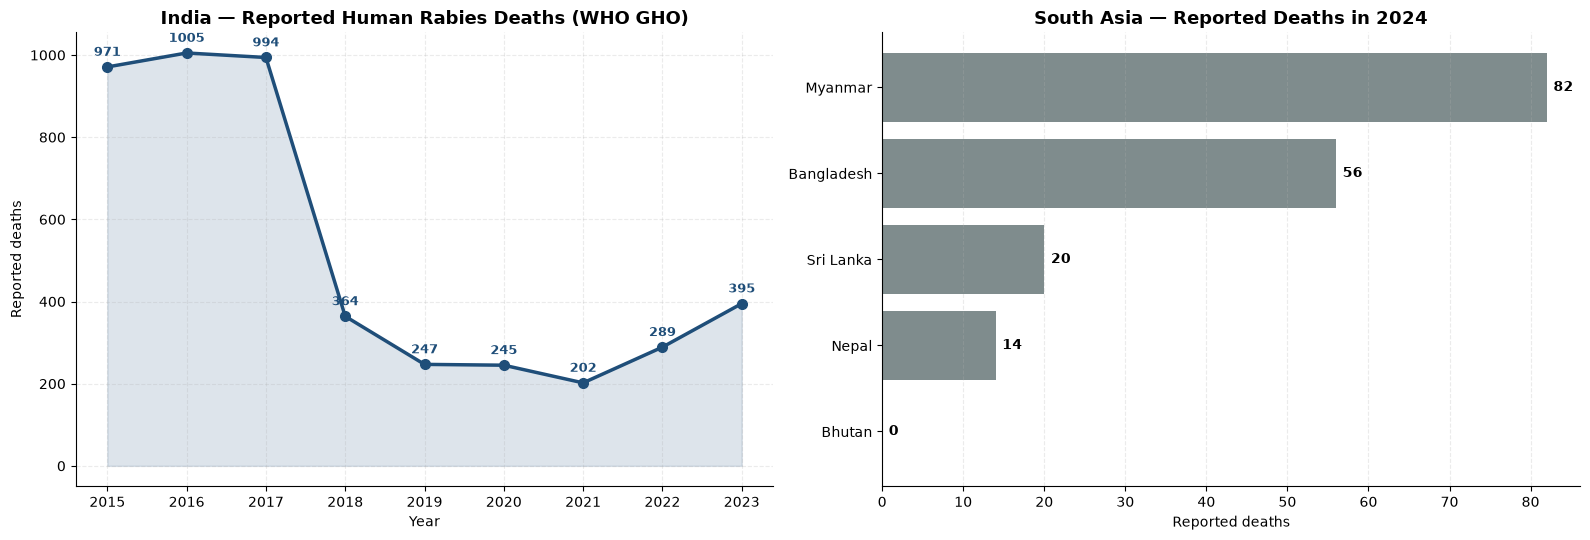


⚠️  Note: WHO data is country-level. No district/state data for Assam.
   District-level data must come from IDSP weekly outbreak reports.


In [3]:
# ============================================================
# COMPONENT 3A: WHO GHO rabies data — India + neighbors
# ============================================================
# What this does:
#   - Filters the NTD_RAB2 dataframe for India and its neighbors
#   - Cleans the data (drops "No data" rows, converts to numeric)
#   - Produces a time-series for charting
#
# What this does NOT do:
#   - Give district-level Assam data. That's not in WHO GHO.
#   - Give "current" cases. WHO GHO lags 1-2 years.

import requests
import pandas as pd
import numpy as np

# --- Base API URL (no auth required) ---
GHO_BASE = "https://ghoapi.azureedge.net/api"
INDICATOR = "NTD_RAB2"  # "Reported number of human rabies deaths"

# --- Pull the full dataset ---
r = requests.get(f"{GHO_BASE}/{INDICATOR}")
r.raise_for_status()
df = pd.DataFrame(r.json()["value"])

# --- Keep only the columns we need ---
df = df[["SpatialDim", "ParentLocation", "TimeDim", "NumericValue"]].copy()
df.columns = ["country_code", "region", "year", "deaths"]

# --- Coerce numeric; WHO uses "No data" strings that become NaN ---
df["year"]   = pd.to_numeric(df["year"],   errors="coerce")
df["deaths"] = pd.to_numeric(df["deaths"], errors="coerce")

# --- Drop rows with no numeric value (unreported) ---
df = df.dropna(subset=["deaths", "year"])
df["year"] = df["year"].astype(int)

print(f"Clean rows: {len(df)}")
print(f"Years: {df['year'].min()}–{df['year'].max()}")
print(f"Countries with at least one year of data: {df['country_code'].nunique()}")

# ============================================================
# India + neighbors (South Asia)
# ============================================================
# These are the countries that share rabies epidemiology context
# with India, especially the Northeast (Assam borders Bangladesh,
# Bhutan, and is near Myanmar).
NEIGHBORS = {
    "IND": "India",
    "PAK": "Pakistan",
    "BGD": "Bangladesh",
    "NPL": "Nepal",
    "BTN": "Bhutan",
    "MMR": "Myanmar",
    "LKA": "Sri Lanka",
}

south_asia = df[df["country_code"].isin(NEIGHBORS.keys())].copy()
south_asia["country"] = south_asia["country_code"].map(NEIGHBORS)

print("\n--- South Asia: reported human rabies deaths ---")
pivot = south_asia.pivot_table(
    index="year", columns="country", values="deaths", aggfunc="sum"
)
print(pivot.to_string())

# ============================================================
# Quick visualization — India trend + South Asia comparison
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), facecolor="white")

# --- Left: India over time ---
ax = axes[0]
india = south_asia[south_asia["country_code"] == "IND"].sort_values("year")
ax.plot(india["year"], india["deaths"],
        marker="o", markersize=7, linewidth=2.5, color="#1f4e79")
ax.fill_between(india["year"], india["deaths"], alpha=0.15, color="#1f4e79")

# Label each point
for _, row in india.iterrows():
    ax.annotate(f"{int(row['deaths'])}",
                (row["year"], row["deaths"]),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=9, fontweight="bold", color="#1f4e79")

ax.set_title("India — Reported Human Rabies Deaths (WHO GHO)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Reported deaths")
ax.grid(alpha=0.25, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- Right: South Asia comparison (latest year) ---
ax = axes[1]
latest = south_asia["year"].max()
latest_df = (south_asia[south_asia["year"] == latest]
             .sort_values("deaths", ascending=True))

colors = ["#c0392b" if c == "India" else "#7f8c8d"
          for c in latest_df["country"]]
bars = ax.barh(latest_df["country"], latest_df["deaths"], color=colors)

for bar, val in zip(bars, latest_df["deaths"]):
    ax.text(bar.get_width() + max(latest_df["deaths"]) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{int(val)}", va="center", fontsize=10, fontweight="bold")

ax.set_title(f"South Asia — Reported Deaths in {latest}",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Reported deaths")
ax.grid(alpha=0.25, linestyle="--", axis="x")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("india_rabies_who.png", dpi=200, bbox_inches="tight")
plt.show()

print("\n⚠️  Note: WHO data is country-level. No district/state data for Assam.")
print("   District-level data must come from IDSP weekly outbreak reports.")

In [13]:
# ============================================================
# ZERO-INSTALL FALLBACK: read shapefile attributes + geometry
# using only the standard library (no pyshp, no fiona)
# ============================================================
import struct
import json

# We'll read .shp (geometry) + .dbf (attributes) manually.
# This is more code but needs zero third-party packages.

SHP_PATH = "geodata/gadm_india/gadm41_IND_2.shp"
DBF_PATH = "geodata/gadm_india/gadm41_IND_2.dbf"

# --- Read DBF (attribute table) ---
def read_dbf(path):
    with open(path, "rb") as f:
        header = f.read(32)
        num_records = struct.unpack("<I", header[4:8])[0]
        header_size = struct.unpack("<H", header[8:10])[0]
        record_size = struct.unpack("<H", header[10:12])[0]

        # Field descriptors (32 bytes each, until 0x0D terminator)
        fields = []
        while True:
            desc = f.read(32)
            if desc[0:1] == b"\x0d":
                break
            name = desc[:11].split(b"\x00")[0].decode("ascii")
            ftype = desc[11:12].decode("ascii")
            flen = desc[16]
            fields.append((name, ftype, flen))

        # Move to records
        f.seek(header_size)
        records = []
        for _ in range(num_records):
            raw = f.read(record_size)
            if raw[0:1] == b"*":  # deleted
                continue
            pos = 1
            rec = {}
            for name, ftype, flen in fields:
                val = raw[pos:pos+flen].decode("latin-1").strip()
                rec[name] = val
                pos += flen
            records.append(rec)
    return records

records = read_dbf(DBF_PATH)
print(f"Read {len(records)} district records.")

# Filter Assam
assam_records = [r for r in records if r.get("NAME_1") == "Assam"]
print(f"Assam districts: {len(assam_records)}")
for r in assam_records[:5]:
    print(f"  {r.get('NAME_2')}")

Read 676 district records.
Assam districts: 27
  Baksa
  Barpeta
  Bongaigaon
  Cachar
  Chirang


In [15]:
# ============================================================
# READ SHAPEFILE GEOMETRY USING ONLY THE STANDARD LIBRARY
# ============================================================
# The .shp format:
#   - 100-byte header (file type, bbox, etc.)
#   - Then a sequence of records. Each record = 8-byte header + content.
#   - For polygons (type 5), content = shape type + bbox + parts + points.
#
# The .shp and .dbf records are 1:1 and in the same order, so we can
# zip geometry[i] with attributes[i].

import struct

SHP_PATH = "geodata/gadm_india/gadm41_IND_2.shp"

def read_shp_polygons(path):
    """Read all polygon records from a .shp file. Returns list of dicts
    with keys: bbox, parts (list of point-list indices), points (list of (x,y))."""
    shapes = []
    with open(path, "rb") as f:
        # --- 100-byte header ---
        header = f.read(100)
        # Bytes 32-36: shape type (little-endian int)
        shape_type = struct.unpack("<i", header[32:36])[0]
        # (shape_type = 5 for polygon)

        # --- Read records until EOF ---
        while True:
            rec_header = f.read(8)
            if len(rec_header) < 8:
                break
            # Record number and content length (in 16-bit words)
            rec_num, content_len_words = struct.unpack(">ii", rec_header)
            content_bytes = content_len_words * 2

            content = f.read(content_bytes)
            if len(content) < content_bytes:
                break

            # --- Content starts with shape type (LE int) ---
            rec_shape_type = struct.unpack("<i", content[0:4])[0]

            # Skip null shapes (type 0)
            if rec_shape_type == 0:
                shapes.append(None)
                continue

            # --- Polygon (type 5) ---
            # Layout after shape type:
            #   4 doubles: Xmin, Ymin, Xmax, Ymax  (32 bytes)
            #   4-byte int: numParts
            #   4-byte int: numPoints
            #   numParts * 4 bytes: parts (start index into points per ring)
            #   numPoints * 16 bytes: points (x, y as doubles)
            bbox = struct.unpack("<4d", content[4:36])
            num_parts  = struct.unpack("<i", content[36:40])[0]
            num_points = struct.unpack("<i", content[40:44])[0]

            parts_offset  = 44
            points_offset = parts_offset + num_parts * 4

            parts = list(struct.unpack(f"<{num_parts}i",
                                       content[parts_offset:points_offset]))

            points = []
            for i in range(num_points):
                off = points_offset + i * 16
                x, y = struct.unpack("<2d", content[off:off+16])
                points.append((x, y))

            shapes.append({
                "type": rec_shape_type,
                "bbox": bbox,
                "parts": parts,
                "points": points,
            })

    return shapes


# --- Read all shapes ---
shapes = read_shp_polygons(SHP_PATH)
print(f"Read {len(shapes)} shape records.")

# --- Sanity check: should equal DBF record count (676) ---
assert len(shapes) == len(records), (
    f"Mismatch: {len(shapes)} shapes vs {len(records)} DBF records"
)
print("✅ Shape and DBF record counts match.")

Read 676 shape records.
✅ Shape and DBF record counts match.


In [16]:
# ============================================================
# BUILD ASSAM GEOJSON (geometry + names)
# ============================================================
# Each shape[i] corresponds to records[i] (same order).

assam_features = []

for shape, rec in zip(shapes, records):
    if rec.get("NAME_1") != "Assam":
        continue
    if shape is None:
        continue

    # --- Convert polygon parts into GeoJSON rings ---
    # A ring is a list of [x, y] pairs. GeoJSON expects closed rings
    # (first point == last point), and GADM already closes them.
    rings = []
    for i, start in enumerate(shape["parts"]):
        end = shape["parts"][i + 1] if i + 1 < len(shape["parts"]) else len(shape["points"])
        ring = [[x, y] for (x, y) in shape["points"][start:end]]
        rings.append(ring)

    # For a single-ring polygon, GeoJSON polygon = [ring]
    # For multi-ring (holes), GeoJSON polygon = [outer, hole1, hole2, ...]
    # For multi-polygons, we'd wrap in a MultiPolygon. For simplicity:
    if len(rings) == 1:
        geometry = {"type": "Polygon", "coordinates": [rings[0]]}
    else:
        geometry = {"type": "MultiPolygon", "coordinates": [[r] for r in rings]}

    assam_features.append({
        "type": "Feature",
        "properties": {
            "NAME_1": rec.get("NAME_1"),
            "NAME_2": rec.get("NAME_2"),
            "GID_2":  rec.get("GID_2"),
        },
        "geometry": geometry,
    })

assam_geojson = {"type": "FeatureCollection", "features": assam_features}

print(f"Assam features: {len(assam_features)}")
for f in assam_features:
    print(f"  {f['properties']['NAME_2']}")

# --- Save to disk for reuse ---
import json
with open("geodata/assam_districts.geojson", "w", encoding="utf-8") as f:
    json.dump(assam_geojson, f)
print("\n✅ Saved geodata/assam_districts.geojson")

Assam features: 27
  Baksa
  Barpeta
  Bongaigaon
  Cachar
  Chirang
  Darrang
  Dhemaji
  Dhubri
  Dibrugarh
  Dima Hasao
  Goalpara
  Golaghat
  Hailakandi
  Jorhat
  Kamrup
  Kamrup Metropolitan
  Karbi Anglong
  Karimganj
  Kokrajhar
  Lakhimpur
  Morigaon
  Nagaon
  Nalbari
  Sivasagar
  Sonitpur
  Tinsukia
  Udalguri

✅ Saved geodata/assam_districts.geojson


In [ ]:
# ============================================================
# LOCATION-AWARE ASSAM DASHBOARD
# ============================================================
# Honest version: takes user location, finds district, shows
# national context + explicit data-gap notice. No fake risk scores.
# Single self-contained HTML. No pip. No server.

import json
import pandas as pd
import requests

# ------------------------------------------------------------
# 1. Fetch WHO GHO India data
# ------------------------------------------------------------
GHO = "https://ghoapi.azureedge.net/api"
r = requests.get(f"{GHO}/NTD_RAB2")
df = pd.DataFrame(r.json()["value"])
df = df[["SpatialDim", "TimeDim", "NumericValue"]].copy()
df.columns = ["country", "year", "deaths"]
df["deaths"] = pd.to_numeric(df["deaths"], errors="coerce")
df["year"]   = pd.to_numeric(df["year"],   errors="coerce")
df = df.dropna(subset=["deaths", "year"])
df["year"] = df["year"].astype(int)

india = df[df["country"] == "IND"].sort_values("year")
india_data = india[["year", "deaths"]].to_dict(orient="records")

# ------------------------------------------------------------
# 2. Load Assam GeoJSON
# ------------------------------------------------------------
with open("geodata/assam_districts.geojson", encoding="utf-8") as f:
    assam_geojson = json.load(f)

# ------------------------------------------------------------
# 3. Build self-contained HTML
# ------------------------------------------------------------
html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Assam Rabies Surveillance — Location View</title>
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<script src="https://cdn.jsdelivr.net/npm/chart.js@4.4.1/dist/chart.umd.min.js"></script>
<style>
  * {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{
    font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif;
    background: #f5f7fa; color: #1a1a1a;
    display: grid;
    grid-template-columns: 400px 1fr;
    grid-template-rows: 64px 1fr;
    grid-template-areas: "header header" "sidebar map";
    height: 100vh;
  }}
  header {{
    grid-area: header;
    background: linear-gradient(135deg, #1f4e79 0%, #2c3e50 100%);
    color: white; display: flex; align-items: center; padding: 0 28px;
    box-shadow: 0 2px 8px rgba(0,0,0,0.15); z-index: 1000;
  }}
  header h1 {{ font-size: 19px; font-weight: 600; }}
  header .subtitle {{
    font-size: 12.5px; opacity: 0.85; margin-left: 16px;
    border-left: 1px solid rgba(255,255,255,0.3); padding-left: 16px;
  }}
  aside {{
    grid-area: sidebar; background: white; overflow-y: auto;
    padding: 20px; border-right: 1px solid #e0e0e0;
  }}
  #map {{ grid-area: map; height: 100%; }}

  .card {{
    background: #fafbfc; border: 1px solid #e1e6ea;
    border-radius: 8px; padding: 14px 16px; margin-bottom: 16px;
  }}
  .card h2 {{
    font-size: 13px; text-transform: uppercase; letter-spacing: 0.6px;
    color: #5a6c7d; margin-bottom: 10px; font-weight: 600;
  }}
  .metric {{
    display: flex; justify-content: space-between; align-items: baseline;
    padding: 8px 0; border-bottom: 1px solid #eef2f5;
  }}
  .metric:last-child {{ border-bottom: none; }}
  .metric-label {{ font-size: 13px; color: #5a6c7d; }}
  .metric-value {{ font-size: 15px; font-weight: 600; color: #1f4e79; }}

  .btn {{
    display: block; width: 100%; padding: 11px 14px;
    background: #1f4e79; color: white; border: none;
    border-radius: 6px; font-size: 14px; font-weight: 600;
    cursor: pointer; margin-bottom: 8px; transition: background 0.15s;
  }}
  .btn:hover {{ background: #2c5f8e; }}
  .btn.secondary {{ background: #eef2f5; color: #1f4e79; }}
  .btn.secondary:hover {{ background: #dde5ec; }}
  .btn:disabled {{ background: #95a5a6; cursor: not-allowed; }}

  .input-group {{ margin-bottom: 10px; }}
  .input-group label {{
    display: block; font-size: 12px; color: #5a6c7d;
    margin-bottom: 4px; font-weight: 500;
  }}
  .input-group input {{
    width: 100%; padding: 9px 11px; border: 1px solid #cfd8dc;
    border-radius: 5px; font-size: 13px;
  }}
  .input-group input:focus {{
    outline: none; border-color: #1f4e79;
  }}

  .row {{ display: flex; gap: 8px; }}
  .row > * {{ flex: 1; }}

  .status {{
    padding: 10px 12px; border-radius: 5px; font-size: 12.5px;
    margin-top: 8px; line-height: 1.5;
  }}
  .status.info    {{ background: #e3f2fd; color: #1565c0; }}
  .status.success {{ background: #e8f5e9; color: #2e7d32; }}
  .status.warn    {{ background: #fff8e1; color: #b8730a; }}
  .status.error   {{ background: #ffebee; color: #c62828; }}

  .disclaimer {{
    background: #fff8e1; border-left: 4px solid #f39c12;
    padding: 12px 14px; font-size: 12px; color: #5c4813;
    line-height: 1.55; border-radius: 4px; margin-top: 12px;
  }}
  .disclaimer strong {{ color: #b8730a; }}

  #chart-container {{
    background: white; border: 1px solid #e1e6ea;
    border-radius: 8px; padding: 12px; height: 180px;
  }}
  #chart-container canvas {{ max-height: 156px; }}

  .attribution {{
    font-size: 10.5px; color: #95a5a6; text-align: center;
    padding: 12px 0 4px; line-height: 1.5;
  }}

  .district-pill {{
    display: inline-block; padding: 3px 10px; border-radius: 12px;
    background: #1f4e79; color: white; font-size: 11px;
    font-weight: 600; margin-left: 6px;
  }}

  .pulse {{
    animation: pulse 1.6s ease-in-out infinite;
  }}
  @keyframes pulse {{
    0%, 100% {{ opacity: 1; }}
    50% {{ opacity: 0.5; }}
  }}
</style>
</head>
<body>

<header>
  <h1>Assam Rabies Surveillance</h1>
  <span class="subtitle">Location-aware prototype · WHO GHO + GADM · Not for clinical use</span>
</header>

<aside>

  <div class="card">
    <h2>Find Your District</h2>

    <button class="btn" id="gpsBtn">📍 Use My Current Location</button>

    <div class="input-group">
      <label>Or enter coordinates</label>
      <div class="row">
        <input type="number" id="latInput" placeholder="Latitude" step="0.0001">
        <input type="number" id="lonInput" placeholder="Longitude" step="0.0001">
      </div>
    </div>

    <button class="btn secondary" id="manualBtn">Locate</button>

    <div id="statusBox"></div>
  </div>

  <div class="card" id="locationCard" style="display:none;">
    <h2>Your Location <span class="district-pill" id="districtPill">—</span></h2>
    <div class="metric">
      <span class="metric-label">Latitude</span>
      <span class="metric-value" id="latOut">—</span>
    </div>
    <div class="metric">
      <span class="metric-label">Longitude</span>
      <span class="metric-value" id="lonOut">—</span>
    </div>
    <div class="metric">
      <span class="metric-label">District</span>
      <span class="metric-value" id="districtOut">—</span>
    </div>
    <div class="metric">
      <span class="metric-label">State</span>
      <span class="metric-value">Assam</span>
    </div>
  </div>

  <div class="card" id="caseCard" style="display:none;">
    <h2>Reported Cases in Your District</h2>
    <div class="metric">
      <span class="metric-label">Reported human rabies cases</span>
      <span class="metric-value" style="color:#c0392b;">Not available</span>
    </div>
    <div class="metric">
      <span class="metric-label">District-level data source</span>
      <span class="metric-value" style="font-size:12px;">IDSP reports not yet parsed</span>
    </div>
    <div class="status warn" style="margin-top:10px;">
      <strong>Zero recorded ≠ rabies-free.</strong> WHO notes rabies is
      severely under-reported. Absence of district-level data in this
      prototype means we simply don't know — not that risk is zero.
    </div>
  </div>

  <div class="card" id="nationalCard" style="display:none;">
    <h2>India — National Context</h2>
    <div class="metric">
      <span class="metric-label">Latest reported year</span>
      <span class="metric-value" id="latestYear">—</span>
    </div>
    <div class="metric">
      <span class="metric-label">Reported deaths (nationwide)</span>
      <span class="metric-value" id="latestDeaths">—</span>
    </div>
    <div id="chart-container" style="margin-top:10px;">
      <canvas id="indiaChart"></canvas>
    </div>
  </div>

  <div class="disclaimer">
    <strong>Data limitation:</strong> WHO GHO (NTD_RAB2) provides
    <em>country-level</em> annual reported deaths. There is
    <strong>no district-level rabies case data</strong> in this prototype.
    District boundaries are from GADM 4.1 and shown for geographic context only.
    This tool does <strong>not</strong> diagnose, assign exposure category, or
    determine PEP urgency. For any animal bite, wash the wound with soap and
    running water for 15+ minutes and seek medical care immediately.
  </div>

  <div class="attribution">
    Boundaries: GADM 4.1 · Data: WHO Global Health Observatory<br>
    Map tiles: OpenStreetMap / CARTO · Prototype, not for clinical use
  </div>
</aside>

<div id="map"></div>

<script>
// ------------------------------------------------------------
// Setup
// ------------------------------------------------------------
const map = L.map('map').setView([26.2, 92.5], 7);

L.tileLayer('https://{{s}}.basemaps.cartocdn.com/light_all/{{z}}/{{x}}/{{y}}{{r}}.png', {{
  attribution: '© OpenStreetMap contributors © CARTO',
  subdomains: 'abcd',
  maxZoom: 18
}}).addTo(map);

const assamGeoJSON = {json.dumps(assam_geojson)};

// Base district layer (light)
const assamLayer = L.geoJSON(assamGeoJSON, {{
  style: {{
    color: '#1f4e79', weight: 1.2,
    fillColor: '#1f4e79', fillOpacity: 0.12
  }},
  onEachFeature: function(feature, layer) {{
    const name = feature.properties.NAME_2 || 'Unknown';
    layer.bindPopup(
      `<b>${{name}}</b><br>` +
      `<span style="color:#7f8c8d;font-size:12px;">` +
      `No district-level case data available in this prototype.</span>`
    );
    layer.on('mouseover', () => layer.setStyle({{ fillOpacity: 0.35 }}));
    layer.on('mouseout',  () => layer.setStyle({{ fillOpacity: 0.12 }}));
  }}
}}).addTo(map);

map.fitBounds(assamLayer.getBounds(), {{ padding: [20, 20] }});

// Guwahati reference star
L.marker([26.1445, 91.7362], {{
  icon: L.divIcon({{
    className: '',
    html: '<div style="font-size:20px;color:#c0392b;text-shadow:0 0 4px white;">★</div>',
    iconSize: [20, 20], iconAnchor: [10, 10]
  }})
}}).addTo(map).bindPopup('<b>Guwahati</b><br>Kamrup Metropolitan district');

// ------------------------------------------------------------
// User location marker + district highlight
// ------------------------------------------------------------
let userMarker = null;
let highlightLayer = null;

function setStatus(msg, type) {{
  const box = document.getElementById('statusBox');
  box.innerHTML = `<div class="status ${{type}}">${{msg}}</div>`;
}}

// Point-in-polygon (ray casting) for GeoJSON polygon rings
function pointInRing(point, ring) {{
  const [x, y] = point;
  let inside = false;
  for (let i = 0, j = ring.length - 1; i < ring.length; j = i++) {{
    const xi = ring[i][0], yi = ring[i][1];
    const xj = ring[j][0], yj = ring[j][1];
    const intersect = ((yi > y) !== (yj > y)) &&
                      (x < (xj - xi) * (y - yi) / (yj - yi) + xi);
    if (intersect) inside = !inside;
  }}
  return inside;
}}

function findDistrict(lat, lon) {{
  const pt = [lon, lat];
  for (const f of assamGeoJSON.features) {{
    const g = f.geometry;
    if (g.type === 'Polygon') {{
      if (pointInRing(pt, g.coordinates[0])) return f;
    }} else if (g.type === 'MultiPolygon') {{
      for (const poly of g.coordinates) {{
        if (pointInRing(pt, poly[0])) return f;
      }}
    }}
  }}
  return null;
}}

function locateUser(lat, lon) {{
  setStatus('Looking up your district…', 'info');

  // Remove old markers/layers
  if (userMarker) map.removeLayer(userMarker);
  if (highlightLayer) map.removeLayer(highlightLayer);

  // Find district
  const feature = findDistrict(lat, lon);

  // Place user marker
  userMarker = L.marker([lat, lon], {{
    icon: L.divIcon({{
      className: '',
      html: '<div style="width:18px;height:18px;background:#e74c3c;border:3px solid white;border-radius:50%;box-shadow:0 0 8px rgba(0,0,0,0.4);"></div>',
      iconSize: [18, 18], iconAnchor: [9, 9]
    }})
  }}).addTo(map).bindPopup('<b>Your location</b>').openPopup();

  // Highlight district
  if (feature) {{
    highlightLayer = L.geoJSON(feature, {{
      style: {{
        color: '#e74c3c', weight: 2.5,
        fillColor: '#e74c3c', fillOpacity: 0.25
      }}
    }}).addTo(map);
    highlightLayer.bringToFront();

    const dname = feature.properties.NAME_2;
    document.getElementById('districtPill').textContent = dname;
    document.getElementById('districtOut').textContent = dname;

    setStatus(`✅ Found: <b>${{dname}}</b> district. No district-level rabies case data available in this prototype.`, 'success');
  }} else {{
    document.getElementById('districtPill').textContent = 'Outside Assam';
    document.getElementById('districtOut').textContent = 'Outside Assam (or in a gap)';
    setStatus('⚠️ Your coordinates don\\'t fall inside any Assam district boundary. Either you are outside Assam, or very close to a border.', 'warn');
  }}

  // Show info cards
  document.getElementById('latOut').textContent = lat.toFixed(5);
  document.getElementById('lonOut').textContent = lon.toFixed(5);
  document.getElementById('locationCard').style.display = 'block';
  document.getElementById('caseCard').style.display = 'block';
  document.getElementById('nationalCard').style.display = 'block';

  // Center map
  map.setView([lat, lon], 9);
}}

// ------------------------------------------------------------
// Buttons
// ------------------------------------------------------------
document.getElementById('gpsBtn').addEventListener('click', () => {{
  if (!navigator.geolocation) {{
    setStatus('Geolocation not supported by this browser.', 'error');
    return;
  }}
  setStatus('Requesting your location…', 'info');
  navigator.geolocation.getCurrentPosition(
    pos => locateUser(pos.coords.latitude, pos.coords.longitude),
    err => setStatus('Location permission denied or unavailable. Enter coordinates manually.', 'error'),
    {{ enableHighAccuracy: true, timeout: 10000 }}
  );
}});

document.getElementById('manualBtn').addEventListener('click', () => {{
  const lat = parseFloat(document.getElementById('latInput').value);
  const lon = parseFloat(document.getElementById('lonInput').value);
  if (isNaN(lat) || isNaN(lon)) {{
    setStatus('Please enter valid latitude and longitude.', 'error');
    return;
  }}
  if (lat < -90 || lat > 90 || lon < -180 || lon > 180) {{
    setStatus('Coordinates out of range.', 'error');
    return;
  }}
  locateUser(lat, lon);
}});

// ------------------------------------------------------------
// India trend chart
// ------------------------------------------------------------
const indiaData = {json.dumps(india_data)};
const years  = indiaData.map(d => d.year);
const deaths = indiaData.map(d => d.deaths);
const latest = indiaData[indiaData.length - 1];
document.getElementById('latestYear').textContent   = latest.year;
document.getElementById('latestDeaths').textContent = latest.deaths.toLocaleString();

new Chart(document.getElementById('indiaChart'), {{
  type: 'line',
  data: {{
    labels: years,
    datasets: [{{
      data: deaths, borderColor: '#1f4e79',
      backgroundColor: 'rgba(31,78,121,0.12)',
      borderWidth: 2.2, fill: true, tension: 0.3,
      pointRadius: 3, pointBackgroundColor: '#1f4e79'
    }}]
  }},
  options: {{
    responsive: true, maintainAspectRatio: false,
    plugins: {{ legend: {{ display: false }} }},
    scales: {{
      x: {{ grid: {{ display: false }}, ticks: {{ font: {{ size: 10 }} }} }},
      y: {{ beginAtZero: true, ticks: {{ font: {{ size: 10 }} }} }}
    }}
  }}
}});
</script>
</body>
</html>
"""

# ------------------------------------------------------------
# 4. Write file
# ------------------------------------------------------------
with open("assam_dashboard_location.html", "w", encoding="utf-8") as f:
    f.write(html)

print("✅ Saved assam_dashboard_location.html")
print(f"   Districts: {len(assam_geojson['features'])}")
print(f"   India trend: {len(india_data)} years (latest {india_data[-1]['year']})")
print("\nOpen in browser. Click 'Use My Current Location' or enter coordinates.")

✅ Saved assam_dashboard_location.html
   Districts: 27
   India trend: 9 years (latest 2023)

Open in browser. Click 'Use My Current Location' or enter coordinates.


In [19]:
import webbrowser
import os

path = os.path.abspath("assam_dashboard_location.html")
print(f"Opening: {path}")
webbrowser.open(f"file:///{path}")

Opening: c:\rabies_experiment_and_system_implementation\notebooks\assam_dashboard_location.html


True

In [25]:
# ============================================================
# RABIES DASHBOARD — global endemic status + India hotspots
# ============================================================
# DATA SOURCES:
#   - Country-level deaths: WHO GHO (NTD_RAB2) — LIVE API ✅
#   - District hotspots: documented in news/health dept reports ⚠️
#   - Assam district cases: ILLUSTRATIVE only (not real surveillance)
#
# HOTSPOT CAVEAT:
#   These coordinates are district headquarters of districts that have
#   been reported in official/news sources for high rabies or dog-bite
#   incidence. They are reference points for proximity estimation —
#   NOT a validated risk map. Rabies is present across India.

import json
import pandas as pd
import requests

# ------------------------------------------------------------
# 1. WHO GHO — country-level reported rabies deaths (LIVE)
# ------------------------------------------------------------
r = requests.get("https://ghoapi.azureedge.net/api/NTD_RAB2")
df = pd.DataFrame(r.json()["value"])
df = df[["SpatialDim", "SpatialDimType", "TimeDim", "NumericValue"]].copy()
df.columns = ["code", "level", "year", "deaths"]
df["deaths"] = pd.to_numeric(df["deaths"], errors="coerce")
df["year"]   = pd.to_numeric(df["year"],   errors="coerce")
df = df.dropna(subset=["deaths", "year"])
df["year"] = df["year"].astype(int)

countries = df[df["level"] == "COUNTRY"]
latest = countries.sort_values("year").groupby("code").tail(1).set_index("code")
country_data = {c: {"year": int(r["year"]), "deaths": float(r["deaths"])}
                for c, r in latest.iterrows()}

india = countries[countries["code"] == "IND"].sort_values("year")
india_data = india[["year", "deaths"]].to_dict(orient="records")

# ------------------------------------------------------------
# 2. Assam GeoJSON boundaries
# ------------------------------------------------------------
with open("geodata/assam_districts.geojson", encoding="utf-8") as f:
    assam_geojson = json.load(f)

# ------------------------------------------------------------
# 3. INDIA HIGH-RISK DISTRICT REFERENCE POINTS
# ------------------------------------------------------------
# Districts with documented high rabies or dog-bite incidence in
# official/state health department reports and press coverage.
# Coordinates are approximate district headquarters.
#
# ⚠️ These are reference points for proximity CONTEXT, not a
#    validated risk map. Rabies is present across India.
HIGH_RISK_DISTRICTS = [
    # --- Karnataka (persistent dog-bite hotspots) ---
    {"state": "Karnataka",       "district": "Vijayapura",         "lat": 16.83,  "lon": 75.71,  "note": "Top dog-bite district"},
    {"state": "Karnataka",       "district": "Hassan",             "lat": 13.00,  "lon": 76.10,  "note": "Top dog-bite district"},
    {"state": "Karnataka",       "district": "Mysuru",             "lat": 12.31,  "lon": 76.65,  "note": "High rabies deaths 2024"},
    {"state": "Karnataka",       "district": "Bengaluru Urban",    "lat": 12.97,  "lon": 77.59,  "note": "High dog-bite load"},

    # --- Kerala (highest dog-bite volume) ---
    {"state": "Kerala",          "district": "Thiruvananthapuram", "lat":  8.52,  "lon": 76.94,  "note": "58k+ bites (2025)"},
    {"state": "Kerala",          "district": "Kollam",             "lat":  8.89,  "lon": 76.61,  "note": "45k+ bites (2025)"},
    {"state": "Kerala",          "district": "Thrissur",           "lat": 10.53,  "lon": 76.21,  "note": "36k+ bites (2025)"},
    {"state": "Kerala",          "district": "Ernakulam",          "lat": 10.00,  "lon": 76.32,  "note": "35k+ bites (2025)"},
    {"state": "Kerala",          "district": "Palakkad",           "lat": 10.78,  "lon": 76.65,  "note": "35k+ bites (2025)"},
    {"state": "Kerala",          "district": "Kannur",             "lat": 11.87,  "lon": 75.37,  "note": "Fox rabies cases 2024"},

    # --- Jammu & Kashmir ---
    {"state": "J&K",             "district": "Jammu",              "lat": 32.73,  "lon": 74.86,  "note": "76k+ bites reported"},
    {"state": "J&K",             "district": "Srinagar",           "lat": 34.08,  "lon": 74.80,  "note": "35k+ bites reported"},
    {"state": "J&K",             "district": "Baramulla",          "lat": 34.20,  "lon": 74.34,  "note": "12k+ bites reported"},
    {"state": "J&K",             "district": "Anantnag",           "lat": 33.73,  "lon": 75.15,  "note": "10k+ bites reported"},

    # --- Maharashtra ---
    {"state": "Maharashtra",     "district": "Pune",               "lat": 18.52,  "lon": 73.85,  "note": "8 rabies deaths (3mo, 2026)"},
    {"state": "Maharashtra",     "district": "Kolhapur",           "lat": 16.70,  "lon": 74.23,  "note": "5 rabies deaths (3mo, 2026)"},
    {"state": "Maharashtra",     "district": "Sangli",             "lat": 16.85,  "lon": 74.58,  "note": "2 rabies deaths (3mo, 2026)"},
    {"state": "Maharashtra",     "district": "Thane",              "lat": 19.22,  "lon": 72.98,  "note": "2 rabies deaths (3mo, 2026)"},
    {"state": "Maharashtra",     "district": "Palghar",            "lat": 19.70,  "lon": 72.77,  "note": "1 rabies death (3mo, 2026)"},

    # --- Tamil Nadu ---
    {"state": "Tamil Nadu",      "district": "Coimbatore",         "lat": 11.02,  "lon": 76.96,  "note": "Suspected rabies death 2024"},
    {"state": "Tamil Nadu",      "district": "Erode",              "lat": 11.34,  "lon": 77.72,  "note": "Suspected rabies death 2024"},

    # --- Himachal Pradesh ---
    {"state": "Himachal Pradesh","district": "Kangra",             "lat": 32.10,  "lon": 76.27,  "note": "Rabies death 2024"},

    # --- Assam (from IDSP weekly alerts) ---
    {"state": "Assam",           "district": "Nagaon",             "lat": 26.35,  "lon": 92.68,  "note": "Rabies case, IDSP report"},
    {"state": "Assam",           "district": "Biswanath",          "lat": 26.73,  "lon": 93.15,  "note": "Human rabies, IDSP report"},
    {"state": "Assam",           "district": "Kamrup Metropolitan","lat": 26.14,  "lon": 91.74,  "note": "State capital, urban stray load"},
    {"state": "Assam",           "district": "Dibrugarh",          "lat": 27.47,  "lon": 94.91,  "note": "Repeated IDSP alerts"},

    # --- Other states (from national reports) ---
    {"state": "Delhi",           "district": "New Delhi",          "lat": 28.61,  "lon": 77.21,  "note": "High urban stray density"},
    {"state": "Uttar Pradesh",   "district": "Lucknow",            "lat": 26.85,  "lon": 80.95,  "note": "State surveillance reports"},
    {"state": "Bihar",           "district": "Patna",              "lat": 25.59,  "lon": 85.14,  "note": "State surveillance reports"},
    {"state": "Gujarat",         "district": "Ahmedabad",          "lat": 23.02,  "lon": 72.57,  "note": "High urban stray density"},
    {"state": "West Bengal",     "district": "Kolkata",            "lat": 22.57,  "lon": 88.36,  "note": "State surveillance reports"},
]

# ------------------------------------------------------------
# 4. Assam district-level ILLUSTRATIVE cases (NOT real)
# ------------------------------------------------------------
# ⚠️ These numbers are placeholder examples to demonstrate how the map
#    renders district-level data. They are NOT actual surveillance counts.
#    Real district-level data requires parsing IDSP weekly PDFs.
ILLUSTRATIVE_CASES = [
    {"district": "Kamrup Metropolitan", "year": 2023, "cases": 4},
    {"district": "Nagaon",              "year": 2023, "cases": 2},
    {"district": "Dibrugarh",           "year": 2023, "cases": 3},
    {"district": "Barpeta",             "year": 2023, "cases": 1},
    {"district": "Cachar",              "year": 2023, "cases": 2},
    {"district": "Sonitpur",            "year": 2023, "cases": 1},
    {"district": "Nalbari",             "year": 2022, "cases": 1},
    {"district": "Golaghat",            "year": 2022, "cases": 1},
]

# ------------------------------------------------------------
# 5. Build HTML
# ------------------------------------------------------------
html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Rabies Information Dashboard</title>
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<script src="https://cdn.jsdelivr.net/npm/chart.js@4.4.1/dist/chart.umd.min.js"></script>
<style>
  * {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{
    font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif;
    background: #f5f7fa; color: #1a1a1a;
    display: grid;
    grid-template-columns: 420px 1fr;
    grid-template-rows: 64px 1fr;
    grid-template-areas: "header header" "sidebar map";
    height: 100vh;
  }}
  header {{
    grid-area: header;
    background: linear-gradient(135deg, #1f4e79 0%, #2c3e50 100%);
    color: white; display: flex; align-items: center; padding: 0 28px;
    box-shadow: 0 2px 8px rgba(0,0,0,0.15); z-index: 1000;
  }}
  header h1 {{ font-size: 19px; font-weight: 600; }}
  header .subtitle {{
    font-size: 12.5px; opacity: 0.85; margin-left: 16px;
    border-left: 1px solid rgba(255,255,255,0.3); padding-left: 16px;
  }}
  aside {{
    grid-area: sidebar; background: white; overflow-y: auto;
    padding: 20px; border-right: 1px solid #e0e0e0;
  }}
  #map {{ grid-area: map; height: 100%; }}

  .card {{
    background: #fafbfc; border: 1px solid #e1e6ea;
    border-radius: 8px; padding: 14px 16px; margin-bottom: 16px;
  }}
  .card h2 {{
    font-size: 13px; text-transform: uppercase; letter-spacing: 0.6px;
    color: #5a6c7d; margin-bottom: 10px; font-weight: 600;
  }}
  .metric {{
    display: flex; justify-content: space-between; align-items: baseline;
    padding: 8px 0; border-bottom: 1px solid #eef2f5;
  }}
  .metric:last-child {{ border-bottom: none; }}
  .metric-label {{ font-size: 13px; color: #5a6c7d; }}
  .metric-value {{ font-size: 15px; font-weight: 600; color: #1f4e79; }}

  .btn {{
    display: block; width: 100%; padding: 11px 14px;
    background: #1f4e79; color: white; border: none;
    border-radius: 6px; font-size: 14px; font-weight: 600;
    cursor: pointer; margin-bottom: 8px;
  }}
  .btn:hover {{ background: #2c5f8e; }}
  .btn.secondary {{ background: #eef2f5; color: #1f4e79; }}
  .btn.secondary:hover {{ background: #dde5ec; }}

  .input-group {{ margin-bottom: 10px; }}
  .input-group label {{
    display: block; font-size: 12px; color: #5a6c7d;
    margin-bottom: 4px; font-weight: 500;
  }}
  .input-group input {{
    width: 100%; padding: 9px 11px; border: 1px solid #cfd8dc;
    border-radius: 5px; font-size: 13px;
  }}
  .row {{ display: flex; gap: 8px; }}
  .row > * {{ flex: 1; }}

  .status {{
    padding: 10px 12px; border-radius: 5px; font-size: 12.5px;
    margin-top: 8px; line-height: 1.5;
  }}
  .status.info    {{ background: #e3f2fd; color: #1565c0; }}
  .status.success {{ background: #e8f5e9; color: #2e7d32; }}
  .status.warn    {{ background: #fff8e1; color: #b8730a; }}
  .status.error   {{ background: #ffebee; color: #c62828; }}

  .endemic-banner {{
    padding: 18px 20px; border-radius: 10px; margin-bottom: 16px;
    border-left: 6px solid; line-height: 1.55;
  }}
  .endemic-banner.endemic   {{ background: #fdeded; border-color: #c0392b; color: #721c1c; }}
  .endemic-banner.non-endemic {{ background: #eaf6ec; border-color: #27ae60; color: #1a4a25; }}
  .endemic-banner.unknown   {{ background: #f0f0f0; border-color: #95a5a6; color: #4a4a4a; }}
  .endemic-banner .banner-title {{
    font-size: 17px; font-weight: 700; margin-bottom: 8px;
  }}
  .endemic-banner .banner-body {{ font-size: 13px; line-height: 1.6; }}

  /* RISK CONTEXT PANEL — the new hotspot-proximity card */
  .risk-panel {{
    padding: 16px 18px; border-radius: 10px;
    margin-bottom: 16px; border: 2px solid; line-height: 1.55;
  }}
  .risk-panel.very-high {{ background: #fde0e0; border-color: #a01b1b; color: #5c0f0f; }}
  .risk-panel.high      {{ background: #fdeded; border-color: #c0392b; color: #721c1c; }}
  .risk-panel.medium    {{ background: #ffe9d6; border-color: #e67e22; color: #7a3b00; }}
  .risk-panel.low       {{ background: #fff8e1; border-color: #f39c12; color: #7a5500; }}
  .risk-panel.far       {{ background: #eaf6ec; border-color: #27ae60; color: #1a4a25; }}

  .risk-panel .risk-header {{
    font-size: 15px; font-weight: 800; margin-bottom: 8px;
    text-transform: uppercase; letter-spacing: 0.8px;
    display: flex; align-items: center; gap: 8px;
  }}
  .risk-panel .risk-distance {{
    font-size: 26px; font-weight: 800; line-height: 1;
    margin: 6px 0;
  }}
  .risk-panel .risk-nearest {{
    font-size: 13px; margin-bottom: 8px; opacity: 0.85;
  }}
  .risk-panel .risk-advice {{
    font-size: 12.5px; line-height: 1.55; margin-top: 10px;
    padding-top: 10px; border-top: 1px solid currentColor;
    opacity: 0.9;
  }}

  .disclaimer {{
    background: #fff8e1; border-left: 4px solid #f39c12;
    padding: 12px 14px; font-size: 12px; color: #5c4813;
    line-height: 1.55; border-radius: 4px; margin-top: 12px;
  }}
  .disclaimer strong {{ color: #b8730a; }}

  .legend-scale {{
    display: flex; align-items: center; gap: 4px;
    font-size: 11px; color: #5a6c7d; margin-top: 6px;
  }}
  .legend-swatch {{
    width: 20px; height: 14px; border: 1px solid #bdc3c7;
  }}

  #chart-container {{
    background: white; border: 1px solid #e1e6ea;
    border-radius: 8px; padding: 12px; height: 180px;
  }}
  #chart-container canvas {{ max-height: 156px; }}

  .attribution {{
    font-size: 10.5px; color: #95a5a6; text-align: center;
    padding: 12px 0 4px; line-height: 1.5;
  }}

  .illustrative-tag {{
    display: inline-block; padding: 2px 8px; border-radius: 10px;
    background: #e67e22; color: white; font-size: 10px;
    font-weight: 700; text-transform: uppercase;
    letter-spacing: 0.5px; margin-left: 6px;
  }}

  .hotspot-tag {{
    display: inline-block; padding: 2px 8px; border-radius: 10px;
    background: #c0392b; color: white; font-size: 10px;
    font-weight: 700; text-transform: uppercase;
    letter-spacing: 0.5px; margin-left: 6px;
  }}

  /* Pulsing hotspot marker on map */
  .hotspot-marker {{
    background: #c0392b; border: 2px solid white;
    border-radius: 50%; box-shadow: 0 0 8px rgba(192,57,43,0.6);
    animation: pulse 2s infinite;
  }}
  @keyframes pulse {{
    0%, 100% {{ box-shadow: 0 0 8px rgba(192,57,43,0.6); }}
    50% {{ box-shadow: 0 0 16px rgba(192,57,43,1); }}
  }}
</style>
</head>
<body>

<header>
  <h1>Rabies Information Dashboard</h1>
  <span class="subtitle">Country status: WHO GHO · India hotspots: documented districts</span>
</header>

<aside>

  <div class="card">
    <h2>Find Your Location</h2>
    <button class="btn" id="gpsBtn">📍 Use My Current Location</button>
    <div class="input-group">
      <label>Or enter coordinates</label>
      <div class="row">
        <input type="number" id="latInput" placeholder="Latitude" step="0.0001">
        <input type="number" id="lonInput" placeholder="Longitude" step="0.0001">
      </div>
    </div>
    <button class="btn secondary" id="manualBtn">Locate</button>
    <div id="statusBox"></div>
  </div>

  <div id="endemicBox" style="display:none;"></div>
  <div id="riskBox" style="display:none;"></div>
  <div id="proximityBox" style="display:none;"></div>

  <div class="card" id="assamContext" style="display:none;">
    <h2>Assam District View <span class="illustrative-tag">Illustrative</span></h2>
    <div class="metric">
      <span class="metric-label">Your district</span>
      <span class="metric-value" id="districtOut">—</span>
    </div>
    <div class="metric">
      <span class="metric-label">Illustrative case count</span>
      <span class="metric-value" id="districtCases">—</span>
    </div>
    <div style="margin-top:10px;">
      <div style="font-size:11px;color:#5a6c7d;margin-bottom:6px;">Assam shading scale (illustrative)</div>
      <div class="legend-scale">
        <span>0</span>
        <span class="legend-swatch" style="background:#ecf0f1;"></span>
        <span class="legend-swatch" style="background:#fff3cd;"></span>
        <span class="legend-swatch" style="background:#ffcc80;"></span>
        <span class="legend-swatch" style="background:#e57373;"></span>
        <span>5+</span>
      </div>
    </div>
    <div class="status warn" style="margin-top:10px;font-size:11.5px;">
      <b>⚠️ Not real surveillance data.</b> Placeholder numbers to show how
      the map works. Real district-level counts for Assam require parsing
      IDSP weekly reports.
    </div>
  </div>

  <div class="card" id="indiaContext" style="display:none;">
    <h2>India Context (WHO GHO)</h2>
    <div class="metric">
      <span class="metric-label">Latest reported year</span>
      <span class="metric-value" id="indiaLatestYear">—</span>
    </div>
    <div class="metric">
      <span class="metric-label">Reported deaths (nationwide)</span>
      <span class="metric-value" id="indiaLatestDeaths">—</span>
    </div>
    <div id="chart-container" style="margin-top:10px;">
      <canvas id="indiaChart"></canvas>
    </div>
  </div>

  <div class="card" id="hotspotListCard">
    <h2>India High-Incidence Districts <span class="hotspot-tag">{len(HIGH_RISK_DISTRICTS)}</span></h2>
    <div style="font-size:11.5px;color:#5a6c7d;margin-bottom:8px;">
      Reference points from published reports. Not a validated risk map.
    </div>
    <div id="hotspotList" style="max-height:220px;overflow-y:auto;font-size:12px;line-height:1.7;"></div>
  </div>

  <div class="card">
    <h2>What to Do If Bitten</h2>
    <ol style="font-size:13px;line-height:1.7;padding-left:20px;color:#2c3e50;">
      <li><b>Wash immediately</b> with soap and running water for <b>15+ minutes</b>.</li>
      <li><b>Go to a hospital today</b> — do not wait.</li>
      <li><b>Get PEP</b> — free at government facilities in India.</li>
      <li>Do <b>not</b> wait for symptoms.</li>
    </ol>
  </div>

  <div class="disclaimer">
    <strong>Critical:</strong> Reported case counts <em>underestimate</em> true burden
    (WHO notes 10–100× under-reporting). <b>Zero reported cases ≠ rabies-free.</b>
    This tool does <b>not</b> diagnose, assign exposure category, or determine PEP
    urgency. <b>Any animal bite, anywhere, requires the same action:</b> wash
    15+ minutes and go to a hospital immediately.
  </div>

  <div class="attribution">
    Boundaries: GADM 4.1 · Country data: WHO GHO · Geocoding: OpenStreetMap Nominatim<br>
    Hotspots: documented district reports · Not for clinical or policy use
  </div>
</aside>

<div id="map"></div>

<script>
// ------------------------------------------------------------
// Setup
// ------------------------------------------------------------
const map = L.map('map').setView([22.5, 79.0], 5);

L.tileLayer('https://{{s}}.tile.openstreetmap.org/{{z}}/{{x}}/{{y}}.png', {{
  attribution: '© OpenStreetMap contributors',
  subdomains: 'abc',
  maxZoom: 19
}}).addTo(map);

// ------------------------------------------------------------
// Data
// ------------------------------------------------------------
const countryData       = {json.dumps(country_data)};
const indiaData         = {json.dumps(india_data)};
const assamGeoJSON      = {json.dumps(assam_geojson)};
const illustrativeCases = {json.dumps(ILLUSTRATIVE_CASES)};
const highRiskDistricts = {json.dumps(HIGH_RISK_DISTRICTS)};

// Rabies-free country list (alpha-3 codes, matches WHO GHO)
const RABIES_FREE = new Set([
  'GBR','IRL','FRA','DEU','NLD','BEL','LUX','CHE','AUT','ITA','ESP','PRT',
  'DNK','SWE','NOR','FIN','ISL','GRC','MLT','CYP',
  'AUS','NZL','PNG','FJI','WSM','TON','VUT','SLB',
  'JPN','KOR','TWN',
  'JAM','BRB','TTO','BHS','CUB','PRI','GRD','LCA','VCT','DMA','ATG','KNA',
  'ISR','JOR','KWT','BHR','QAT','ARE','OMN','SAU',
  'SGP','MUS','SYC','MDV','CPV','STP','MHL','FSM','PLW','NRU','TUV','KIR',
  'COK','NIU','WLF','PYF','NCL',
  'MCO','SMR','LIE','AND','VAT',
]);

// ISO alpha-2 → alpha-3 bridge
const ALPHA2_TO_ALPHA3 = {{
  'AF':'AFG','AL':'ALB','DZ':'DZA','AD':'AND','AO':'AGO','AR':'ARG','AM':'ARM',
  'AU':'AUS','AT':'AUT','AZ':'AZE','BS':'BHS','BH':'BHR','BD':'BGD','BB':'BRB',
  'BY':'BLR','BE':'BEL','BZ':'BLZ','BJ':'BEN','BT':'BTN','BO':'BOL','BA':'BIH',
  'BW':'BWA','BR':'BRA','BN':'BRN','BG':'BGR','BF':'BFA','BI':'BDI','KH':'KHM',
  'CM':'CMR','CA':'CAN','CV':'CPV','CF':'CAF','TD':'TCD','CL':'CHL','CN':'CHN',
  'CO':'COL','KM':'COM','CD':'COD','CG':'COG','CR':'CRI','CI':'CIV','HR':'HRV',
  'CU':'CUB','CY':'CYP','CZ':'CZE','DK':'DNK','DJ':'DJI','DM':'DMA','DO':'DOM',
  'EC':'ECU','EG':'EGY','SV':'SLV','GQ':'GNQ','ER':'ERI','EE':'EST','SZ':'SWZ',
  'ET':'ETH','FJ':'FJI','FI':'FIN','FR':'FRA','GA':'GAB','GM':'GMB','GE':'GEO',
  'DE':'DEU','GH':'GHA','GR':'GRC','GD':'GRD','GT':'GTM','GN':'GIN','GW':'GNB',
  'GY':'GUY','HT':'HTI','HN':'HND','HU':'HUN','IS':'ISL','IN':'IND','ID':'IDN',
  'IR':'IRN','IQ':'IRQ','IE':'IRL','IL':'ISR','IT':'ITA','JM':'JAM','JP':'JPN',
  'JO':'JOR','KZ':'KAZ','KE':'KEN','KI':'KIR','KP':'PRK','KR':'KOR','KW':'KWT',
  'KG':'KGZ','LA':'LAO','LV':'LVA','LB':'LBN','LS':'LSO','LR':'LBR','LY':'LBY',
  'LI':'LIE','LT':'LTU','LU':'LUX','MG':'MDG','MW':'MWI','MY':'MYS','MV':'MDV',
  'ML':'MLI','MT':'MLT','MH':'MHL','MR':'MRT','MU':'MUS','MX':'MEX','FM':'FSM',
  'MD':'MDA','MC':'MCO','MN':'MNG','ME':'MNE','MA':'MAR','MZ':'MOZ','MM':'MMR',
  'NA':'NAM','NR':'NRU','NP':'NPL','NL':'NLD','NZ':'NZL','NI':'NIC','NE':'NER',
  'NG':'NGA','MK':'MKD','NO':'NOR','OM':'OMN','PK':'PAK','PW':'PLW','PA':'PAN',
  'PG':'PNG','PY':'PRY','PE':'PER','PH':'PHL','PL':'POL','PT':'PRT','QA':'QAT',
  'RO':'ROU','RU':'RUS','RW':'RWA','KN':'KNA','LC':'LCA','VC':'VCT','WS':'WSM',
  'SM':'SMR','ST':'STP','SA':'SAU','SN':'SEN','RS':'SRB','SC':'SYC','SL':'SLE',
  'SG':'SGP','SK':'SVK','SI':'SVN','SB':'SLB','SO':'SOM','ZA':'ZAF','SS':'SSD',
  'ES':'ESP','LK':'LKA','SD':'SDN','SR':'SUR','SE':'SWE','CH':'CHE','SY':'SYR',
  'TW':'TWN','TJ':'TJK','TZ':'TZA','TH':'THA','TL':'TLS','TG':'TGO','TO':'TON',
  'TT':'TTO','TN':'TUN','TR':'TUR','TM':'TKM','TV':'TUV','UG':'UGA','UA':'UKR',
  'AE':'ARE','GB':'GBR','US':'USA','UY':'URY','UZ':'UZB','VU':'VUT','VE':'VEN',
  'VN':'VNM','YE':'YEM','ZM':'ZMB','ZW':'ZWE',
}};

// ------------------------------------------------------------
// Haversine distance (km)
// ------------------------------------------------------------
function haversine(lat1, lon1, lat2, lon2) {{
  const R = 6371;
  const toRad = d => d * Math.PI / 180;
  const dLat = toRad(lat2 - lat1);
  const dLon = toRad(lon2 - lon1);
  const a = Math.sin(dLat/2)**2 +
            Math.cos(toRad(lat1)) * Math.cos(toRad(lat2)) *
            Math.sin(dLon/2)**2;
  return R * 2 * Math.asin(Math.sqrt(a));
}}

// ------------------------------------------------------------
// Render hotspot markers on the map
// ------------------------------------------------------------
const hotspotMarkers = [];
for (const d of highRiskDistricts) {{
  const marker = L.circleMarker([d.lat, d.lon], {{
    radius: 8,
    color: '#721c1c',
    weight: 2,
    fillColor: '#c0392b',
    fillOpacity: 0.85,
  }}).addTo(map);
  marker.bindPopup(
    `<b>${{d.district}}</b><br>` +
    `<span style="color:#5a6c7d;font-size:12px;">${{d.state}}</span><br>` +
    `<span style="color:#c0392b;font-size:12px;font-weight:600;">` +
    `High-incidence district</span><br>` +
    `<span style="font-size:11px;color:#7f8c8d;">${{d.note}}</span>`
  );
  hotspotMarkers.push({{ ...d, marker }});
}}

// ------------------------------------------------------------
// Populate sidebar hotspot list
// ------------------------------------------------------------
const listEl = document.getElementById('hotspotList');
listEl.innerHTML = highRiskDistricts
  .map(d => `<div style="padding:4px 0;border-bottom:1px solid #eef2f5;">` +
            `<b style="color:#c0392b;">${{d.district}}</b> ` +
            `<span style="color:#7f8c8d;">— ${{d.state}}</span>` +
            `</div>`)
  .join('');

// ------------------------------------------------------------
// Assam district centroids + illustrative cases
// ------------------------------------------------------------
function ringCentroid(ring) {{
  let sx = 0, sy = 0;
  for (const [x, y] of ring) {{ sx += x; sy += y; }}
  return [sy / ring.length, sx / ring.length];
}}
function districtCentroid(feature) {{
  const g = feature.geometry;
  if (g.type === 'Polygon') return ringCentroid(g.coordinates[0]);
  let best = g.coordinates[0][0];
  for (const poly of g.coordinates) {{
    if (poly[0].length > best.length) best = poly[0];
  }}
  return ringCentroid(best);
}}

const districtInfo = {{}};
for (const f of assamGeoJSON.features) {{
  const name = f.properties.NAME_2;
  const [lat, lon] = districtCentroid(f);
  districtInfo[name] = {{ lat, lon, cases: 0, year: null }};
}}
for (const c of illustrativeCases) {{
  if (districtInfo[c.district]) {{
    districtInfo[c.district].cases += c.cases;
    districtInfo[c.district].year   = c.year;
  }}
}}

function colorForCases(n) {{
  if (n === 0)  return '#ecf0f1';
  if (n <= 1)   return '#fff3cd';
  if (n <= 3)   return '#ffcc80';
  return '#e57373';
}}

const assamLayer = L.geoJSON(assamGeoJSON, {{
  style: function(feature) {{
    const name = feature.properties.NAME_2;
    const n = districtInfo[name] ? districtInfo[name].cases : 0;
    return {{
      color: '#1f4e79',
      weight: 1.2,
      fillColor: colorForCases(n),
      fillOpacity: 0.65,
    }};
  }},
  onEachFeature: function(feature, layer) {{
    const name = feature.properties.NAME_2;
    const info = districtInfo[name] || {{cases: 0}};
    layer.bindPopup(
      `<b>${{name}}</b><br>` +
      `Illustrative count: <b>${{info.cases}}</b> ` +
      `${{info.year ? '(latest ' + info.year + ')' : ''}}<br>` +
      `<span style="font-size:11px;color:#c0392b;font-weight:600;">` +
      `⚠️ Not real surveillance data</span>`
    );
    layer.on('mouseover', () => layer.setStyle({{ weight: 2.5 }}));
    layer.on('mouseout',  () => layer.setStyle({{ weight: 1.2 }}));
  }}
}}).addTo(map);

// ------------------------------------------------------------
// Compute nearest hotspot + risk level
// ------------------------------------------------------------
// Thresholds (km) — for CONTEXT, not clinical triage.
const RISK_LEVELS = [
  {{ max: 50,  level: 'very-high', label: 'VERY CLOSE',
     advice: 'You are within ~50 km of a documented high-incidence district. ' +
             'Rabies is present in the animal population here. ' +
             'Any animal bite: wash wound 15+ minutes, go to a hospital immediately.' }},
  {{ max: 150, level: 'high',      label: 'CLOSE',
     advice: 'You are within ~150 km of a documented high-incidence district. ' +
             'Treat any animal bite with full seriousness. ' +
             'Wash 15+ minutes and seek medical care the same day.' }},
  {{ max: 300, level: 'medium',    label: 'MODERATE',
     advice: 'You are within ~300 km of a documented high-incidence district. ' +
             'Rabies is endemic across India. Any animal bite requires the same response: ' +
             'wash 15+ minutes and go to a hospital.' }},
  {{ max: 600, level: 'low',       label: 'DISTANT',
     advice: 'You are ~600 km or less from the nearest documented hotspot. ' +
             'Risk is not zero anywhere in India. ' +
             'Any animal bite: wash 15+ minutes and seek care immediately.' }},
  {{ max: Infinity, level: 'far',  label: 'FAR',
     advice: 'You are far from the documented hotspots in our dataset. ' +
             'Rabies is present across mainland India. ' +
             'Any animal bite: wash 15+ minutes and seek care immediately.' }},
];

function findNearestHotspot(userLat, userLon) {{
  let nearest = null;
  let minDist = Infinity;
  for (const d of highRiskDistricts) {{
    const dist = haversine(userLat, userLon, d.lat, d.lon);
    if (dist < minDist) {{ minDist = dist; nearest = d; }}
  }}
  return {{ nearest, distance: minDist }};
}}

function getRiskLevel(distanceKm) {{
  for (const r of RISK_LEVELS) {{
    if (distanceKm <= r.max) return r;
  }}
  return RISK_LEVELS[RISK_LEVELS.length - 1];
}}

// ------------------------------------------------------------
// Render risk panel
// ------------------------------------------------------------
function renderRiskPanel(userLat, userLon) {{
  const box = document.getElementById('riskBox');
  box.style.display = 'block';

  const {{ nearest, distance }} = findNearestHotspot(userLat, userLon);
  const risk = getRiskLevel(distance);

  box.innerHTML = `
    <div class="risk-panel ${{risk.level}}">
      <div class="risk-header">
        <span>${{risk.level === 'far' ? '✅' :
                 risk.level === 'low' ? '🟢' :
                 risk.level === 'medium' ? '🟠' :
                 risk.level === 'high' ? '🔴' : '🚨'}}</span>
        <span>Hotspot Proximity: ${{risk.label}}</span>
      </div>
      <div class="risk-distance">${{Math.round(distance)}} km</div>
      <div class="risk-nearest">
        Nearest documented hotspot:<br>
        <b>${{nearest.district}}</b>, ${{nearest.state}}
      </div>
      <div class="risk-advice">${{risk.advice}}</div>
    </div>
  `;
}}

// ------------------------------------------------------------
// Illustrative Assam proximity (kept as secondary info)
// ------------------------------------------------------------
const RADIUS_KM = 75;
function renderAssamProximity(userLat, userLon, inAssam) {{
  const box = document.getElementById('proximityBox');
  box.style.display = 'block';

  if (!inAssam) {{
    box.innerHTML = `
      <div class="risk-panel low" style="background:#f4f6f8;border-color:#95a5a6;color:#4a4a4a;">
        <div class="risk-header">📊 Assam District View</div>
        <div style="font-size:12.5px;line-height:1.55;">
          District-level view is currently <b>Assam-only</b> in our prototype.
          For locations outside Assam, refer to the hotspot proximity panel above.
          <b>Zero recorded ≠ zero risk.</b>
        </div>
      </div>
    `;
    return;
  }}

  let totalCases = 0;
  const nearby = [];
  for (const [name, info] of Object.entries(districtInfo)) {{
    if (info.cases === 0) continue;
    const d = haversine(userLat, userLon, info.lat, info.lon);
    if (d <= RADIUS_KM) {{
      totalCases += info.cases;
      nearby.push({{ name, distance: d, cases: info.cases }});
    }}
  }}
  nearby.sort((a, b) => a.distance - b.distance);

  let detailHtml = '';
  if (nearby.length > 0) {{
    detailHtml = '<div style="margin-top:6px;font-size:12px;">' +
                 '<b>Nearest districts (illustrative):</b><ul style="margin-top:4px;padding-left:18px;">';
    for (const n of nearby.slice(0, 5)) {{
      detailHtml += `<li>${{n.name}} — ${{n.cases}} (illustrative) · ${{n.distance.toFixed(0)}} km</li>`;
    }}
    detailHtml += '</ul></div>';
  }}

  box.innerHTML = `
    <div class="risk-panel low">
      <div class="risk-header">📊 Assam District View (Illustrative)</div>
      <div class="risk-distance">${{totalCases}}</div>
      <div style="font-size:12px;">Illustrative count within ${{RADIUS_KM}} km</div>
      ${{detailHtml}}
      <div style="margin-top:10px;font-size:11.5px;opacity:0.85;">
        <b>⚠️ Placeholder numbers, not real surveillance data.</b>
      </div>
    </div>
  `;
}}

// ------------------------------------------------------------
// Reverse geocoding
// ------------------------------------------------------------
async function reverseGeocode(lat, lon) {{
  const url = `https://nominatim.openstreetmap.org/reverse?format=json&lat=${{lat}}&lon=${{lon}}&zoom=5&addressdetails=1`;
  const resp = await fetch(url, {{ headers: {{ 'Accept-Language': 'en' }} }});
  if (!resp.ok) throw new Error("Geocoding failed");
  const data = await resp.json();
  const a = data.address || {{}};

  const alpha2 = a.country_code ? a.country_code.toUpperCase() : null;
  const alpha3 = alpha2 ? (ALPHA2_TO_ALPHA3[alpha2] || alpha2) : null;

  return {{
    country: a.country || null,
    countryCode: alpha3,
    state: a.state || null,
  }};
}}

// ------------------------------------------------------------
// Endemic banner
// ------------------------------------------------------------
function renderEndemic(code, name) {{
  const box = document.getElementById('endemicBox');
  box.style.display = 'block';

  const isFree = RABIES_FREE.has(code);
  const data = countryData[code];
  const reported = data ? data.deaths : null;
  const year = data ? data.year : null;

  let cls, title, body;
  if (isFree) {{
    cls = 'non-endemic';
    title = `✅ ${{name}} — Reported rabies-free`;
    body = `WHO recognizes ${{name}} as free of dog-mediated human rabies. Even so, if bitten, wash 15+ min and seek care.`;
  }} else if (reported !== null) {{
    cls = 'endemic';
    title = `⚠️ ${{name}} — Rabies-endemic`;
    body = `Rabies is present in animal populations. WHO recorded <b>${{reported.toLocaleString()}}</b> reported human deaths in <b>${{year}}</b>. Under-reporting is severe.`;
  }} else {{
    cls = 'unknown';
    title = `ℹ️ ${{name}} — Status unclear in our data`;
    body = `No WHO GHO case data available. Treat as potentially endemic.`;
  }}

  box.innerHTML = `
    <div class="endemic-banner ${{cls}}">
      <div class="banner-title">${{title}}</div>
      <div class="banner-body">${{body}}</div>
    </div>
  `;
}}

// ------------------------------------------------------------
// Locate handler
// ------------------------------------------------------------
let userMarker = null;
let radiusCircle = null;

async function locateUser(lat, lon) {{
  const statusBox = document.getElementById('statusBox');
  statusBox.innerHTML = `<div class="status info">Looking up your location…</div>`;

  if (userMarker) map.removeLayer(userMarker);
  if (radiusCircle) map.removeLayer(radiusCircle);

  userMarker = L.marker([lat, lon], {{
    icon: L.divIcon({{
      className: '',
      html: '<div style="width:20px;height:20px;background:#2980b9;border:3px solid white;border-radius:50%;box-shadow:0 0 10px rgba(0,0,0,0.6);"></div>',
      iconSize: [20, 20], iconAnchor: [10, 10]
    }})
  }}).addTo(map).bindPopup('<b>Your location</b>').openPopup();

  // Draw a 150 km radius circle around user (visual context)
  radiusCircle = L.circle([lat, lon], {{
    radius: 150000, // meters
    color: '#2980b9',
    weight: 1,
    opacity: 0.5,
    fillColor: '#2980b9',
    fillOpacity: 0.06,
    dashArray: '4 4',
  }}).addTo(map);

  const inAssam = assamLayer.getBounds().contains([lat, lon]);

  // Risk panel (hotspots proximity) — the PRIMARY output
  renderRiskPanel(lat, lon);

  // Assam-specific panel (illustrative)
  renderAssamProximity(lat, lon, inAssam);

  // Reverse geocode for country status
  let geo;
  try {{
    geo = await reverseGeocode(lat, lon);
  }} catch (e) {{
    statusBox.innerHTML = `<div class="status error">Geocoding failed. Proximity info still shown.</div>`;
    return;
  }}

  const cCode = geo.countryCode;
  const cName = geo.country || cCode || 'Unknown';
  if (!cCode) {{
    statusBox.innerHTML = `<div class="status warn">Coordinates resolved to ${{cName}}.</div>`;
    return;
  }}

  statusBox.innerHTML = `<div class="status success">✅ Located: <b>${{cName}}</b></div>`;
  renderEndemic(cCode, cName);

  if (cCode === 'IND') {{
    document.getElementById('indiaContext').style.display = 'block';
    if (inAssam) {{
      document.getElementById('assamContext').style.display = 'block';
      let foundName = '—', foundCases = '—', bestDist = Infinity;
      for (const [dname, info] of Object.entries(districtInfo)) {{
        const d = haversine(lat, lon, info.lat, info.lon);
        if (d < bestDist) {{
          bestDist = d;
          foundName = dname;
          foundCases = info.cases;
        }}
      }}
      document.getElementById('districtOut').textContent = foundName;
      document.getElementById('districtCases').textContent = foundCases + ' (illustrative)';
    }}
  }}

  // Zoom appropriately
  map.setView([lat, lon], inAssam ? 8 : 6);
}}

// ------------------------------------------------------------
// Buttons
// ------------------------------------------------------------
document.getElementById('gpsBtn').addEventListener('click', () => {{
  if (!navigator.geolocation) {{
    document.getElementById('statusBox').innerHTML =
      '<div class="status error">Geolocation not supported.</div>';
    return;
  }}
  document.getElementById('statusBox').innerHTML =
    '<div class="status info">Requesting your location…</div>';
  navigator.geolocation.getCurrentPosition(
    pos => locateUser(pos.coords.latitude, pos.coords.longitude),
    err => {{
      document.getElementById('statusBox').innerHTML =
        '<div class="status error">Location denied. Enter coordinates.</div>';
    }},
    {{ enableHighAccuracy: true, timeout: 10000 }}
  );
}});

document.getElementById('manualBtn').addEventListener('click', () => {{
  const lat = parseFloat(document.getElementById('latInput').value);
  const lon = parseFloat(document.getElementById('lonInput').value);
  if (isNaN(lat) || isNaN(lon)) {{
    document.getElementById('statusBox').innerHTML =
      '<div class="status error">Enter valid coordinates.</div>';
    return;
  }}
  locateUser(lat, lon);
}});

// ------------------------------------------------------------
// India trend chart
// ------------------------------------------------------------
if (indiaData.length > 0) {{
  const years  = indiaData.map(d => d.year);
  const deaths = indiaData.map(d => d.deaths);
  const latest = indiaData[indiaData.length - 1];
  document.getElementById('indiaLatestYear').textContent   = latest.year;
  document.getElementById('indiaLatestDeaths').textContent = latest.deaths.toLocaleString();

  new Chart(document.getElementById('indiaChart'), {{
    type: 'line',
    data: {{
      labels: years,
      datasets: [{{
        data: deaths, borderColor: '#1f4e79',
        backgroundColor: 'rgba(31,78,121,0.12)',
        borderWidth: 2.2, fill: true, tension: 0.3,
        pointRadius: 3, pointBackgroundColor: '#1f4e79'
      }}]
    }},
    options: {{
      responsive: true, maintainAspectRatio: false,
      plugins: {{ legend: {{ display: false }} }},
      scales: {{
        x: {{ grid: {{ display: false }}, ticks: {{ font: {{ size: 10 }} }} }},
        y: {{ beginAtZero: true, ticks: {{ font: {{ size: 10 }} }} }}
      }}
    }}
  }});
}}
</script>
</body>
</html>
"""

with open("rabies_dashboard_cases.html", "w", encoding="utf-8") as f:
    f.write(html)

print("✅ Saved rabies_dashboard_cases.html")
print(f"   Assam districts (boundaries): {len(assam_geojson['features'])}")
print(f"   India high-risk hotspots:     {len(HIGH_RISK_DISTRICTS)}")
print(f"   Illustrative Assam cases:     {len(ILLUSTRATIVE_CASES)} (NOT real)")
print()
print("Test coordinates:")
print("  Guwahati (Assam):       26.1445,  91.7362  -> close to Kamrup Metro hotspot")
print("  Pune (Maharashtra):     18.5204,  73.8567  -> very close to Pune hotspot")
print("  Kollam (Kerala):         8.8932,  76.6141  -> very close to Kollam hotspot")
print("  Kangra (HP):            32.0998,  76.2691  -> very close to Kangra hotspot")
print("  London (UK):            51.5074, -0.1278   -> rabies-free country")
print("  Karachi (Pakistan):     24.8607,  67.0011  -> Pakistan endemic")

✅ Saved rabies_dashboard_cases.html
   Assam districts (boundaries): 27
   India high-risk hotspots:     31
   Illustrative Assam cases:     8 (NOT real)

Test coordinates:
  Guwahati (Assam):       26.1445,  91.7362  -> close to Kamrup Metro hotspot
  Pune (Maharashtra):     18.5204,  73.8567  -> very close to Pune hotspot
  Kollam (Kerala):         8.8932,  76.6141  -> very close to Kollam hotspot
  Kangra (HP):            32.0998,  76.2691  -> very close to Kangra hotspot
  London (UK):            51.5074, -0.1278   -> rabies-free country
  Karachi (Pakistan):     24.8607,  67.0011  -> Pakistan endemic


In [28]:
# ============================================================
# COMPONENT 5 — FUSION ENGINE (SELF-CONTAINED)
# ============================================================
# Combines 3 signals:
#   1. Wound photo (WILLIE)        → is there a visible wound?
#   2. Location (hotspot distance) → how close to a documented hotspot?
#   3. Questionnaire (WHO/NRCP)    → what exposure category?
#
# Output: urgency tier + honest time-window language + reasoning.
#
# CRITICAL SAFETY:
#   This does NOT invent a safe waiting period.
#   WHO/NRCP say "start PEP as soon as possible" — period.
#   The fusion only adjusts HOW URGENTLY we say that.

import json
import base64
import numpy as np
import torch
import torch.nn.functional as F
import cv2
from pathlib import Path
from PIL import Image
from torchvision import transforms

# ------------------------------------------------------------
# 0. SELF-CONTAINED DEPENDENCIES
# ------------------------------------------------------------
# Re-load model and resolve image path — no reliance on earlier cells.

from huggingface_hub import hf_hub_download
from willie_model import ModelConfig, WILLIEModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

weights_path = hf_hub_download(
    repo_id="QianGroup/willie-weights",
    filename="mini/willie_mini_fold0_best.pt"
)
ckpt = torch.load(weights_path, map_location="cpu", weights_only=False)
cfg = ModelConfig(**ckpt["config"])
model = WILLIEModel(cfg).to(device)
model.load_state_dict(ckpt["model_state_dict"], strict=True)
model.eval()
print("✅ WILLIE loaded and in eval mode")

# --- Resolve IMAGE_PATH robustly ---
CANDIDATES = [
    Path.cwd() / "sample_wound.jpg",
    Path.cwd().parent / "sample_wound.jpg",
    Path(r"c:\rabies_experiment_and_system_implementation\sample_wound.jpg"),
]
IMAGE_PATH = None
for c in CANDIDATES:
    print(f"Checking: {c}  ->  exists={c.exists()}")
    if c.exists():
        IMAGE_PATH = c
        break
if IMAGE_PATH is None:
    raise FileNotFoundError(
        "sample_wound.jpg not found. Save it to one of:\n"
        + "\n".join(f"  {c}" for c in CANDIDATES)
    )
print(f"✅ Using image: {IMAGE_PATH}\n")


# ------------------------------------------------------------
# 1. Wound photo analysis via WILLIE
# ------------------------------------------------------------
def analyze_wound_photo(image_path, model, device, top_percent=5.0):
    """Run WILLIE on one photo. Return a compact wound summary."""
    INPUT_SIZE = 518
    preprocess = transforms.Compose([
        transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise FileNotFoundError(f"Could not read {image_path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    tensor = preprocess(Image.fromarray(img_rgb)).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(tensor)

    seg_prob = torch.sigmoid(out["seg_mask"])[0, 0].cpu().numpy()
    cutoff = np.percentile(seg_prob.flatten(), 100 - top_percent)
    seg_bin = (seg_prob >= cutoff).astype(np.uint8)
    area_pct = float(seg_bin.sum() / seg_bin.size * 100)

    peak_prob = float(seg_prob.max())
    has_wound = bool(peak_prob > 0.7 and 0.5 < area_pct < 40)

    CLASSES = ["diabetic", "pressure", "surgical", "venous", "no_wound"]
    probs = F.softmax(out["cls_logits"], dim=1)[0].cpu().numpy()
    cls_idx = int(probs.argmax())

    return {
        "has_wound": has_wound,
        "area_pct":  round(area_pct, 2),
        "peak_prob": round(peak_prob, 3),
        "cls_class": CLASSES[cls_idx],
        "cls_conf":  round(float(probs[cls_idx]), 3),
    }


WOUND_RESULT = analyze_wound_photo(IMAGE_PATH, model, device)
print("Wound photo analysis:")
print(json.dumps(WOUND_RESULT, indent=2))


# ------------------------------------------------------------
# 2. High-risk hotspot reference points
# ------------------------------------------------------------
HIGH_RISK_DISTRICTS = [
    {"state": "Karnataka",       "district": "Vijayapura",         "lat": 16.83,  "lon": 75.71},
    {"state": "Karnataka",       "district": "Hassan",             "lat": 13.00,  "lon": 76.10},
    {"state": "Karnataka",       "district": "Mysuru",             "lat": 12.31,  "lon": 76.65},
    {"state": "Karnataka",       "district": "Bengaluru Urban",    "lat": 12.97,  "lon": 77.59},
    {"state": "Kerala",          "district": "Thiruvananthapuram", "lat":  8.52,  "lon": 76.94},
    {"state": "Kerala",          "district": "Kollam",             "lat":  8.89,  "lon": 76.61},
    {"state": "Kerala",          "district": "Thrissur",           "lat": 10.53,  "lon": 76.21},
    {"state": "Kerala",          "district": "Ernakulam",          "lat": 10.00,  "lon": 76.32},
    {"state": "Kerala",          "district": "Palakkad",           "lat": 10.78,  "lon": 76.65},
    {"state": "Kerala",          "district": "Kannur",             "lat": 11.87,  "lon": 75.37},
    {"state": "J&K",             "district": "Jammu",              "lat": 32.73,  "lon": 74.86},
    {"state": "J&K",             "district": "Srinagar",           "lat": 34.08,  "lon": 74.80},
    {"state": "J&K",             "district": "Baramulla",          "lat": 34.20,  "lon": 74.34},
    {"state": "J&K",             "district": "Anantnag",           "lat": 33.73,  "lon": 75.15},
    {"state": "Maharashtra",     "district": "Pune",               "lat": 18.52,  "lon": 73.85},
    {"state": "Maharashtra",     "district": "Kolhapur",           "lat": 16.70,  "lon": 74.23},
    {"state": "Maharashtra",     "district": "Sangli",             "lat": 16.85,  "lon": 74.58},
    {"state": "Maharashtra",     "district": "Thane",              "lat": 19.22,  "lon": 72.98},
    {"state": "Maharashtra",     "district": "Palghar",            "lat": 19.70,  "lon": 72.77},
    {"state": "Tamil Nadu",      "district": "Coimbatore",         "lat": 11.02,  "lon": 76.96},
    {"state": "Tamil Nadu",      "district": "Erode",              "lat": 11.34,  "lon": 77.72},
    {"state": "Himachal Pradesh","district": "Kangra",             "lat": 32.10,  "lon": 76.27},
    {"state": "Assam",           "district": "Nagaon",             "lat": 26.35,  "lon": 92.68},
    {"state": "Assam",           "district": "Biswanath",          "lat": 26.73,  "lon": 93.15},
    {"state": "Assam",           "district": "Kamrup Metropolitan","lat": 26.14,  "lon": 91.74},
    {"state": "Assam",           "district": "Dibrugarh",          "lat": 27.47,  "lon": 94.91},
    {"state": "Delhi",           "district": "New Delhi",          "lat": 28.61,  "lon": 77.21},
    {"state": "Uttar Pradesh",   "district": "Lucknow",            "lat": 26.85,  "lon": 80.95},
    {"state": "Bihar",           "district": "Patna",              "lat": 25.59,  "lon": 85.14},
    {"state": "Gujarat",         "district": "Ahmedabad",          "lat": 23.02,  "lon": 72.57},
    {"state": "West Bengal",     "district": "Kolkata",            "lat": 22.57,  "lon": 88.36},
]

c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


Using cache found in C:\Users\Lenovo/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\Lenovo/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Lenovo/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Lenovo/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


✅ WILLIE loaded and in eval mode
Checking: c:\rabies_experiment_and_system_implementation\notebooks\sample_wound.jpg  ->  exists=False
Checking: c:\rabies_experiment_and_system_implementation\sample_wound.jpg  ->  exists=True
✅ Using image: c:\rabies_experiment_and_system_implementation\sample_wound.jpg

Wound photo analysis:
{
  "has_wound": true,
  "area_pct": 5.0,
  "peak_prob": 0.984,
  "cls_class": "venous",
  "cls_conf": 0.662
}


In [4]:
# ============================================================
# COMBINED DASHBOARD — Wound AI + Hotspot + Questionnaire + Fusion
# ============================================================
# Single self-contained HTML file combining everything.
# The screenshot you showed = the sidebar of this page.

import json
import base64
import numpy as np
import cv2
from pathlib import Path

# ------------------------------------------------------------
# 0. Ensure dependencies exist (self-contained after restart)
# ------------------------------------------------------------
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from huggingface_hub import hf_hub_download
from willie_model import ModelConfig, WILLIEModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Load WILLIE if not already in memory ---
if 'WOUND_RESULT' not in dir():
    print("Loading WILLIE model...")
    weights_path = hf_hub_download(
        repo_id="QianGroup/willie-weights",
        filename="mini/willie_mini_fold0_best.pt"
    )
    ckpt = torch.load(weights_path, map_location="cpu", weights_only=False)
    cfg = ModelConfig(**ckpt["config"])
    model = WILLIEModel(cfg).to(device)
    model.load_state_dict(ckpt["model_state_dict"], strict=True)
    model.eval()

    CANDIDATES = [
        Path.cwd() / "sample_wound.jpg",
        Path.cwd().parent / "sample_wound.jpg",
        Path(r"c:\rabies_experiment_and_system_implementation\sample_wound.jpg"),
    ]
    IMAGE_PATH = next((c for c in CANDIDATES if c.exists()), None)
    assert IMAGE_PATH, "sample_wound.jpg not found"

    preprocess = transforms.Compose([
        transforms.Resize((518, 518)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    img_bgr = cv2.imread(str(IMAGE_PATH))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    tensor = preprocess(Image.fromarray(img_rgb)).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(tensor)

    seg_prob = torch.sigmoid(out["seg_mask"])[0, 0].cpu().numpy()
    cutoff = np.percentile(seg_prob.flatten(), 95)
    seg_bin = (seg_prob >= cutoff).astype(np.uint8)
    area_pct = float(seg_bin.sum() / seg_bin.size * 100)
    peak_prob = float(seg_prob.max())

    CLASSES = ["diabetic", "pressure", "surgical", "venous", "no_wound"]
    probs = F.softmax(out["cls_logits"], dim=1)[0].cpu().numpy()

    WOUND_RESULT = {
        "has_wound": bool(peak_prob > 0.7 and 0.5 < area_pct < 40),
        "area_pct":  round(area_pct, 2),
        "peak_prob": round(peak_prob, 3),
        "cls_class": CLASSES[int(probs.argmax())],
        "cls_conf":  round(float(probs.max()), 3),
    }

# --- Ensure IMAGE_PATH exists for thumbnail ---
if 'IMAGE_PATH' not in dir():
    CANDIDATES = [
        Path.cwd() / "sample_wound.jpg",
        Path.cwd().parent / "sample_wound.jpg",
        Path(r"c:\rabies_experiment_and_system_implementation\sample_wound.jpg"),
    ]
    IMAGE_PATH = next((c for c in CANDIDATES if c.exists()), None)

print("Wound result:", WOUND_RESULT)

# ------------------------------------------------------------
# 1. Country-level data (WHO GHO)
# ------------------------------------------------------------
import requests
import pandas as pd

r = requests.get("https://ghoapi.azureedge.net/api/NTD_RAB2")
df = pd.DataFrame(r.json()["value"])
df = df[["SpatialDim", "SpatialDimType", "TimeDim", "NumericValue"]].copy()
df.columns = ["code", "level", "year", "deaths"]
df["deaths"] = pd.to_numeric(df["deaths"], errors="coerce")
df["year"]   = pd.to_numeric(df["year"],   errors="coerce")
df = df.dropna(subset=["deaths", "year"])
df["year"] = df["year"].astype(int)
countries = df[df["level"] == "COUNTRY"]
latest = countries.sort_values("year").groupby("code").tail(1).set_index("code")
country_data = {c: {"year": int(r["year"]), "deaths": float(r["deaths"])}
                for c, r in latest.iterrows()}
india = countries[countries["code"] == "IND"].sort_values("year")
india_data = india[["year", "deaths"]].to_dict(orient="records")

# ------------------------------------------------------------
# 2. Assam GeoJSON
# ------------------------------------------------------------
with open("geodata/assam_districts.geojson", encoding="utf-8") as f:
    assam_geojson = json.load(f)

# ------------------------------------------------------------
# 3. Hotspot + illustrative data
# ------------------------------------------------------------
HIGH_RISK_DISTRICTS = [
    {"state":"Karnataka","district":"Vijayapura","lat":16.83,"lon":75.71},
    {"state":"Karnataka","district":"Hassan","lat":13.00,"lon":76.10},
    {"state":"Karnataka","district":"Mysuru","lat":12.31,"lon":76.65},
    {"state":"Karnataka","district":"Bengaluru Urban","lat":12.97,"lon":77.59},
    {"state":"Kerala","district":"Thiruvananthapuram","lat":8.52,"lon":76.94},
    {"state":"Kerala","district":"Kollam","lat":8.89,"lon":76.61},
    {"state":"Kerala","district":"Thrissur","lat":10.53,"lon":76.21},
    {"state":"Kerala","district":"Ernakulam","lat":10.00,"lon":76.32},
    {"state":"Kerala","district":"Palakkad","lat":10.78,"lon":76.65},
    {"state":"Kerala","district":"Kannur","lat":11.87,"lon":75.37},
    {"state":"J&K","district":"Jammu","lat":32.73,"lon":74.86},
    {"state":"J&K","district":"Srinagar","lat":34.08,"lon":74.80},
    {"state":"J&K","district":"Baramulla","lat":34.20,"lon":74.34},
    {"state":"J&K","district":"Anantnag","lat":33.73,"lon":75.15},
    {"state":"Maharashtra","district":"Pune","lat":18.52,"lon":73.85},
    {"state":"Maharashtra","district":"Kolhapur","lat":16.70,"lon":74.23},
    {"state":"Maharashtra","district":"Sangli","lat":16.85,"lon":74.58},
    {"state":"Maharashtra","district":"Thane","lat":19.22,"lon":72.98},
    {"state":"Maharashtra","district":"Palghar","lat":19.70,"lon":72.77},
    {"state":"Tamil Nadu","district":"Coimbatore","lat":11.02,"lon":76.96},
    {"state":"Tamil Nadu","district":"Erode","lat":11.34,"lon":77.72},
    {"state":"Himachal Pradesh","district":"Kangra","lat":32.10,"lon":76.27},
    {"state":"Assam","district":"Nagaon","lat":26.35,"lon":92.68},
    {"state":"Assam","district":"Biswanath","lat":26.73,"lon":93.15},
    {"state":"Assam","district":"Kamrup Metropolitan","lat":26.14,"lon":91.74},
    {"state":"Assam","district":"Dibrugarh","lat":27.47,"lon":94.91},
    {"state":"Delhi","district":"New Delhi","lat":28.61,"lon":77.21},
    {"state":"Uttar Pradesh","district":"Lucknow","lat":26.85,"lon":80.95},
    {"state":"Bihar","district":"Patna","lat":25.59,"lon":85.14},
    {"state":"Gujarat","district":"Ahmedabad","lat":23.02,"lon":72.57},
    {"state":"West Bengal","district":"Kolkata","lat":22.57,"lon":88.36},
]

ILLUSTRATIVE_CASES = [
    {"district": "Kamrup Metropolitan", "year": 2023, "cases": 4},
    {"district": "Nagaon",              "year": 2023, "cases": 2},
    {"district": "Dibrugarh",           "year": 2023, "cases": 3},
    {"district": "Barpeta",             "year": 2023, "cases": 1},
    {"district": "Cachar",              "year": 2023, "cases": 2},
    {"district": "Sonitpur",            "year": 2023, "cases": 1},
    {"district": "Nalbari",             "year": 2022, "cases": 1},
    {"district": "Golaghat",            "year": 2022, "cases": 1},
]

# ------------------------------------------------------------
# 4. Thumbnail as base64
# ------------------------------------------------------------
img_bgr = cv2.imread(str(IMAGE_PATH))
thumb = cv2.resize(img_bgr, (144, 144), interpolation=cv2.INTER_AREA)
_, buf = cv2.imencode('.jpg', thumb, [cv2.IMWRITE_JPEG_QUALITY, 80])
thumb_b64 = "data:image/jpeg;base64," + base64.b64encode(buf).decode('ascii')

# ------------------------------------------------------------
# 5. Build HTML
# ------------------------------------------------------------
html = r"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Rabies Triage + Surveillance Dashboard</title>
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css"/>
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
<script src="https://cdn.jsdelivr.net/npm/chart.js@4.4.1/dist/chart.umd.min.js"></script>
<style>
  * { box-sizing: border-box; margin: 0; padding: 0; }
  body {
    font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif;
    background: #f5f7fa; color: #1a1a1a;
    display: grid;
    grid-template-columns: 460px 1fr;
    grid-template-rows: 64px 1fr;
    grid-template-areas: "header header" "sidebar map";
    height: 100vh;
  }
  header {
    grid-area: header;
    background: linear-gradient(135deg, #1f4e79 0%, #2c3e50 100%);
    color: white; display: flex; align-items: center; padding: 0 28px;
    box-shadow: 0 2px 8px rgba(0,0,0,0.15); z-index: 1000;
  }
  header h1 { font-size: 19px; font-weight: 600; }
  header .subtitle {
    font-size: 12.5px; opacity: 0.85; margin-left: 16px;
    border-left: 1px solid rgba(255,255,255,0.3); padding-left: 16px;
  }
  aside {
    grid-area: sidebar; background: white; overflow-y: auto;
    padding: 16px; border-right: 1px solid #e0e0e0;
  }
  #map { grid-area: map; height: 100%; }

  .card {
    background: #fafbfc; border: 1px solid #e1e6ea;
    border-radius: 8px; padding: 14px 16px; margin-bottom: 14px;
  }
  .card h2 {
    font-size: 12px; text-transform: uppercase; letter-spacing: 0.6px;
    color: #5a6c7d; margin-bottom: 10px; font-weight: 700;
  }

  .safety-banner {
    background: #fff8e1; border-left: 4px solid #f39c12;
    padding: 12px 14px; font-size: 12.5px; color: #5c4813;
    line-height: 1.55; border-radius: 6px; margin-bottom: 14px;
  }
  .safety-banner b { color: #b8730a; }

  /* Wound card */
  .wound-card {
    border: 2px solid #e1e6ea; border-radius: 10px; padding: 12px;
    display: flex; gap: 12px; align-items: center; background: #fafbfc;
    margin-bottom: 14px;
  }
  .wound-card.has-wound { border-color: #e67e22; background: #fff8e1; }
  .wound-card.no-wound  { border-color: #bdc3c7; background: #f4f6f8; }
  .wound-thumb {
    width: 84px; height: 84px; border-radius: 8px; object-fit: cover;
    border: 2px solid white; box-shadow: 0 2px 8px rgba(0,0,0,0.15);
    flex-shrink: 0; cursor: pointer;
  }
  .wound-thumb:hover { opacity: 0.85; }
  .wound-info { flex: 1; }
  .wound-info .w-title { font-size: 14px; font-weight: 700; }
  .wound-info .w-sub { font-size: 12px; color: #5a6c7d; margin-top: 4px; line-height: 1.4; }

  /* Location */
  .btn {
    display: block; width: 100%; padding: 11px 14px;
    background: #1f4e79; color: white; border: none;
    border-radius: 6px; font-size: 13.5px; font-weight: 600;
    cursor: pointer; margin-bottom: 8px;
  }
  .btn:hover { background: #2c5f8e; }
  .btn.secondary { background: #eef2f5; color: #1f4e79; }
  .btn.secondary:hover { background: #dde5ec; }
  .input-group { margin-bottom: 10px; }
  .input-group label {
    display: block; font-size: 12px; color: #5a6c7d;
    margin-bottom: 4px; font-weight: 500;
  }
  .input-group input {
    width: 100%; padding: 9px 11px; border: 1px solid #cfd8dc;
    border-radius: 5px; font-size: 13px;
  }
  .row { display: flex; gap: 8px; }
  .row > * { flex: 1; }

  .status {
    padding: 10px 12px; border-radius: 5px; font-size: 12.5px;
    margin-top: 8px; line-height: 1.5;
  }
  .status.info    { background: #e3f2fd; color: #1565c0; }
  .status.success { background: #e8f5e9; color: #2e7d32; }
  .status.warn    { background: #fff8e1; color: #b8730a; }
  .status.error   { background: #ffebee; color: #c62828; }

  /* Endemic banner */
  .endemic-banner {
    padding: 16px 18px; border-radius: 10px; margin-bottom: 14px;
    border-left: 6px solid; line-height: 1.55;
  }
  .endemic-banner.endemic   { background: #fdeded; border-color: #c0392b; color: #721c1c; }
  .endemic-banner.non-endemic { background: #eaf6ec; border-color: #27ae60; color: #1a4a25; }
  .endemic-banner.unknown   { background: #f0f0f0; border-color: #95a5a6; color: #4a4a4a; }
  .endemic-banner .banner-title {
    font-size: 16px; font-weight: 700; margin-bottom: 6px;
  }
  .endemic-banner .banner-body { font-size: 12.5px; line-height: 1.6; }

  /* Risk panels */
  .risk-panel {
    padding: 16px 18px; border-radius: 10px;
    margin-bottom: 14px; border: 2px solid; line-height: 1.55;
  }
  .risk-panel.very-high { background: #fde0e0; border-color: #a01b1b; color: #5c0f0f; }
  .risk-panel.high      { background: #fdeded; border-color: #c0392b; color: #721c1c; }
  .risk-panel.medium    { background: #ffe9d6; border-color: #e67e22; color: #7a3b00; }
  .risk-panel.low       { background: #fff8e1; border-color: #f39c12; color: #7a5500; }
  .risk-panel.far       { background: #eaf6ec; border-color: #27ae60; color: #1a4a25; }
  .risk-panel.tier-emergency     { background: #fde0e0; border-color: #a01b1b; color: #5c0f0f; }
  .risk-panel.tier-today-urgent  { background: #fdeded; border-color: #c0392b; color: #721c1c; }
  .risk-panel.tier-today         { background: #ffe9d6; border-color: #e67e22; color: #7a3b00; }
  .risk-panel.tier-today-caution { background: #fff8e1; border-color: #f39c12; color: #7a5500; }
  .risk-panel.tier-monitor       { background: #eaf6ec; border-color: #27ae60; color: #1a4a25; }

  .risk-panel .risk-header {
    font-size: 14px; font-weight: 800; margin-bottom: 8px;
    text-transform: uppercase; letter-spacing: 0.8px;
    display: flex; align-items: center; gap: 8px;
  }
  .risk-panel .risk-distance {
    font-size: 26px; font-weight: 800; line-height: 1; margin: 6px 0;
  }
  .risk-panel .risk-nearest {
    font-size: 13px; margin-bottom: 8px; opacity: 0.9;
  }
  .risk-panel .risk-advice {
    font-size: 12.5px; line-height: 1.55; margin-top: 10px;
    padding-top: 10px; border-top: 1px solid currentColor; opacity: 0.92;
  }

  .illustrative-tag {
    display: inline-block; padding: 2px 8px; border-radius: 10px;
    background: #e67e22; color: white; font-size: 10px;
    font-weight: 700; text-transform: uppercase;
    letter-spacing: 0.5px; margin-left: 6px;
  }

  /* Questionnaire */
  .q-meta { font-size: 11px; color: #95a5a6; text-transform: uppercase;
            letter-spacing: 0.8px; font-weight: 600; margin-bottom: 6px; }
  .q-title { font-size: 17px; font-weight: 700; line-height: 1.3; margin-bottom: 6px; }
  .q-help  { font-size: 12.5px; color: #5a6c7d; margin-bottom: 10px; }
  .opt {
    display: block; width: 100%; padding: 13px 15px;
    background: #fafbfc; border: 2px solid #e1e6ea;
    border-radius: 8px; text-align: left; cursor: pointer;
    font-family: inherit; font-size: 14px; font-weight: 600; color: #1a1a1a;
    transition: all 0.15s; margin-bottom: 8px;
  }
  .opt:hover { border-color: #1f4e79; background: #f0f5fa; }
  .opt .sub { display: block; font-size: 12px; font-weight: 400;
              color: #7f8c8d; margin-top: 3px; }

  /* Scrollable hotspot list */
  #hotspotList { max-height: 180px; overflow-y: auto; font-size: 12px; line-height: 1.7; }
  #hotspotList > div { padding: 3px 0; border-bottom: 1px solid #eef2f5; }

  #chart-container {
    background: white; border: 1px solid #e1e6ea;
    border-radius: 8px; padding: 10px; height: 160px; margin-top: 10px;
  }
  #chart-container canvas { max-height: 140px; }

  .attribution {
    font-size: 10.5px; color: #95a5a6; text-align: center;
    padding: 10px 0 4px; line-height: 1.5;
  }
</style>
</head>
<body>

<header>
  <h1>Rabies Triage + Surveillance Dashboard</h1>
  <span class="subtitle">Wound AI · Hotspot proximity · WHO/NRCP exposure · Not for clinical use</span>
</header>

<aside>

  <!-- Persistent safety banner -->
  <div class="safety-banner">
    <b>⚠️ Always do this first:</b> Wash the wound with soap and running water
    for <b>15+ minutes</b>, then go to a hospital or clinic the same day.
    Do not wait for symptoms.
  </div>

  <!-- WOUND PHOTO CARD -->
  <div class="wound-card" id="woundCard">
    <img id="woundThumb" class="wound-thumb" alt="Wound photo" title="Click to upload a different image"/>
    <div class="wound-info">
      <div class="w-title" id="woundTitle">—</div>
      <div class="w-sub" id="woundSub">—</div>
    </div>
  </div>
  <input type="file" id="fileInput" accept="image/*" style="display:none"/>

  <!-- LOCATION -->
  <div class="card">
    <h2>Find Your Location</h2>
    <button class="btn" id="gpsBtn">📍 Use My Current Location</button>
    <div class="input-group">
      <label>Or enter coordinates</label>
      <div class="row">
        <input type="number" id="latInput" placeholder="Latitude" step="0.0001">
        <input type="number" id="lonInput" placeholder="Longitude" step="0.0001">
      </div>
    </div>
    <button class="btn secondary" id="manualBtn">Locate</button>
    <div id="statusBox"></div>
  </div>

  <!-- Dynamic panels — fill after location -->
  <div id="endemicBox" style="display:none;"></div>
  <div id="riskBox" style="display:none;"></div>
  <div id="assamContext" style="display:none;" class="card">
    <h2>Assam District View <span class="illustrative-tag">Illustrative</span></h2>
    <div style="display:flex;justify-content:space-between;padding:6px 0;">
      <span style="font-size:13px;color:#5a6c7d;">Your district</span>
      <span style="font-size:14px;font-weight:600;" id="districtOut">—</span>
    </div>
    <div style="display:flex;justify-content:space-between;padding:6px 0;">
      <span style="font-size:13px;color:#5a6c7d;">Illustrative count</span>
      <span style="font-size:14px;font-weight:600;" id="districtCases">—</span>
    </div>
    <div class="status warn" style="margin-top:8px;font-size:11.5px;">
      <b>⚠️ Not real surveillance data.</b> Placeholder numbers to demonstrate
      the interface. Real district counts require IDSP parsing.
    </div>
  </div>

  <!-- QUESTIONNAIRE -->
  <div class="card" id="questionCard">
    <h2>Exposure Triage</h2>
    <div id="questionScreen">
      <div class="q-meta" id="qMeta">Question 1 of 5</div>
      <div class="q-title" id="qTitle">—</div>
      <div class="q-help" id="qHelp">—</div>
      <div id="qOptions"></div>
      <div id="qNav"></div>
    </div>
  </div>

  <!-- FUSION RESULT -->
  <div id="fusionBox" style="display:none;"></div>

  <!-- INDIA CONTEXT -->
  <div class="card" id="indiaContext" style="display:none;">
    <h2>India Context (WHO GHO)</h2>
    <div style="display:flex;justify-content:space-between;padding:6px 0;">
      <span style="font-size:13px;color:#5a6c7d;">Latest reported year</span>
      <span style="font-size:14px;font-weight:600;" id="indiaLatestYear">—</span>
    </div>
    <div style="display:flex;justify-content:space-between;padding:6px 0;">
      <span style="font-size:13px;color:#5a6c7d;">Reported deaths</span>
      <span style="font-size:14px;font-weight:600;" id="indiaLatestDeaths">—</span>
    </div>
    <div id="chart-container"><canvas id="indiaChart"></canvas></div>
  </div>

  <!-- HOTSPOT LIST -->
  <div class="card">
    <h2>India High-Incidence Districts</h2>
    <div id="hotspotList"></div>
  </div>

  <div class="attribution">
    Boundaries: GADM 4.1 · Country data: WHO GHO · Geocoding: Nominatim<br>
    Prototype — not for clinical use
  </div>
</aside>

<div id="map"></div>

<script>
// ============================================================
// INJECTED DATA
// ============================================================
const WOUND_RESULT        = __WOUND_RESULT__;
const WOUND_THUMB_B64     = "__WOUND_THUMB_B64__";
const HIGH_RISK_DISTRICTS = __HOTSPOTS__;
const countryData         = __COUNTRY_DATA__;
const indiaData           = __INDIA_DATA__;
const assamGeoJSON        = __ASSAM_GEOJSON__;
const illustrativeCases   = __ILLUSTRATIVE_CASES__;

const RABIES_FREE = new Set([
  'GBR','IRL','FRA','DEU','NLD','BEL','LUX','CHE','AUT','ITA','ESP','PRT',
  'DNK','SWE','NOR','FIN','ISL','GRC','MLT','CYP',
  'AUS','NZL','PNG','FJI','WSM','TON','VUT','SLB',
  'JPN','KOR','TWN',
  'JAM','BRB','TTO','BHS','CUB','PRI','GRD','LCA','VCT','DMA','ATG','KNA',
  'ISR','JOR','KWT','BHR','QAT','ARE','OMN','SAU',
  'SGP','MUS','SYC','MDV','CPV','STP','MHL','FSM','PLW','NRU','TUV','KIR',
  'COK','NIU','WLF','PYF','NCL',
  'MCO','SMR','LIE','AND','VAT',
]);

const ALPHA2_TO_ALPHA3 = {
  'AF':'AFG','AL':'ALB','DZ':'DZA','AD':'AND','AO':'AGO','AR':'ARG','AM':'ARM',
  'AU':'AUS','AT':'AUT','AZ':'AZE','BS':'BHS','BH':'BHR','BD':'BGD','BB':'BRB',
  'BY':'BLR','BE':'BEL','BZ':'BLZ','BJ':'BEN','BT':'BTN','BO':'BOL','BA':'BIH',
  'BW':'BWA','BR':'BRA','BN':'BRN','BG':'BGR','BF':'BFA','BI':'BDI','KH':'KHM',
  'CM':'CMR','CA':'CAN','CV':'CPV','CF':'CAF','TD':'TCD','CL':'CHL','CN':'CHN',
  'CO':'COL','KM':'COM','CD':'COD','CG':'COG','CR':'CRI','CI':'CIV','HR':'HRV',
  'CU':'CUB','CY':'CYP','CZ':'CZE','DK':'DNK','DJ':'DJI','DM':'DMA','DO':'DOM',
  'EC':'ECU','EG':'EGY','SV':'SLV','GQ':'GNQ','ER':'ERI','EE':'EST','SZ':'SWZ',
  'ET':'ETH','FJ':'FJI','FI':'FIN','FR':'FRA','GA':'GAB','GM':'GMB','GE':'GEO',
  'DE':'DEU','GH':'GHA','GR':'GRC','GD':'GRD','GT':'GTM','GN':'GIN','GW':'GNB',
  'GY':'GUY','HT':'HTI','HN':'HND','HU':'HUN','IS':'ISL','IN':'IND','ID':'IDN',
  'IR':'IRN','IQ':'IRQ','IE':'IRL','IL':'ISR','IT':'ITA','JM':'JAM','JP':'JPN',
  'JO':'JOR','KZ':'KAZ','KE':'KEN','KI':'KIR','KP':'PRK','KR':'KOR','KW':'KWT',
  'KG':'KGZ','LA':'LAO','LV':'LVA','LB':'LBN','LS':'LSO','LR':'LBR','LY':'LBY',
  'LI':'LIE','LT':'LTU','LU':'LUX','MG':'MDG','MW':'MWI','MY':'MYS','MV':'MDV',
  'ML':'MLI','MT':'MLT','MH':'MHL','MR':'MRT','MU':'MUS','MX':'MEX','FM':'FSM',
  'MD':'MDA','MC':'MCO','MN':'MNG','ME':'MNE','MA':'MAR','MZ':'MOZ','MM':'MMR',
  'NA':'NAM','NR':'NRU','NP':'NPL','NL':'NLD','NZ':'NZL','NI':'NIC','NE':'NER',
  'NG':'NGA','MK':'MKD','NO':'NOR','OM':'OMN','PK':'PAK','PW':'PLW','PA':'PAN',
  'PG':'PNG','PY':'PRY','PE':'PER','PH':'PHL','PL':'POL','PT':'PRT','QA':'QAT',
  'RO':'ROU','RU':'RUS','RW':'RWA','KN':'KNA','LC':'LCA','VC':'VCT','WS':'WSM',
  'SM':'SMR','ST':'STP','SA':'SAU','SN':'SEN','RS':'SRB','SC':'SYC','SL':'SLE',
  'SG':'SGP','SK':'SVK','SI':'SVN','SB':'SLB','SO':'SOM','ZA':'ZAF','SS':'SSD',
  'ES':'ESP','LK':'LKA','SD':'SDN','SR':'SUR','SE':'SWE','CH':'CHE','SY':'SYR',
  'TW':'TWN','TJ':'TJK','TZ':'TZA','TH':'THA','TL':'TLS','TG':'TGO','TO':'TON',
  'TT':'TTO','TN':'TUN','TR':'TUR','TM':'TKM','TV':'TUV','UG':'UGA','UA':'UKR',
  'AE':'ARE','GB':'GBR','US':'USA','UY':'URY','UZ':'UZB','VU':'VUT','VE':'VEN',
  'VN':'VNM','YE':'YEM','ZM':'ZMB','ZW':'ZWE',
};

// ============================================================
// MAP SETUP
// ============================================================
const map = L.map('map').setView([22.5, 79.0], 5);
L.tileLayer('https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png', {
  attribution: '© OpenStreetMap contributors',
  subdomains: 'abc', maxZoom: 19
}).addTo(map);

// ============================================================
// HAVERSINE
// ============================================================
function haversine(lat1, lon1, lat2, lon2) {
  const R = 6371, toRad = d => d * Math.PI / 180;
  const dLat = toRad(lat2 - lat1), dLon = toRad(lon2 - lon1);
  const a = Math.sin(dLat/2)**2 +
            Math.cos(toRad(lat1)) * Math.cos(toRad(lat2)) *
            Math.sin(dLon/2)**2;
  return R * 2 * Math.asin(Math.sqrt(a));
}

// ============================================================
// HOTSPOT MARKERS ON MAP
// ============================================================
for (const d of HIGH_RISK_DISTRICTS) {
  L.circleMarker([d.lat, d.lon], {
    radius: 7, color: '#721c1c', weight: 2,
    fillColor: '#c0392b', fillOpacity: 0.85,
  }).addTo(map).bindPopup(`<b>${d.district}</b><br>${d.state}`);
}

// Populate hotspot list
document.getElementById('hotspotList').innerHTML = HIGH_RISK_DISTRICTS
  .map(d => `<div><b style="color:#c0392b;">${d.district}</b> ` +
            `<span style="color:#7f8c8d;">— ${d.state}</span></div>`)
  .join('');

// ============================================================
// ASSAM DISTRICT POLYGONS
// ============================================================
function ringCentroid(ring) {
  let sx = 0, sy = 0;
  for (const [x, y] of ring) { sx += x; sy += y; }
  return [sy / ring.length, sx / ring.length];
}
function districtCentroid(feature) {
  const g = feature.geometry;
  if (g.type === 'Polygon') return ringCentroid(g.coordinates[0]);
  let best = g.coordinates[0][0];
  for (const poly of g.coordinates) {
    if (poly[0].length > best.length) best = poly[0];
  }
  return ringCentroid(best);
}
const districtInfo = {};
for (const f of assamGeoJSON.features) {
  const name = f.properties.NAME_2;
  const [lat, lon] = districtCentroid(f);
  districtInfo[name] = { lat, lon, cases: 0, year: null };
}
for (const c of illustrativeCases) {
  if (districtInfo[c.district]) {
    districtInfo[c.district].cases += c.cases;
    districtInfo[c.district].year   = c.year;
  }
}
function colorForCases(n) {
  if (n === 0) return '#ecf0f1';
  if (n <= 1) return '#fff3cd';
  if (n <= 3) return '#ffcc80';
  return '#e57373';
}
const assamLayer = L.geoJSON(assamGeoJSON, {
  style: f => {
    const name = f.properties.NAME_2;
    const n = districtInfo[name] ? districtInfo[name].cases : 0;
    return { color: '#1f4e79', weight: 1.2, fillColor: colorForCases(n), fillOpacity: 0.65 };
  },
  onEachFeature: (f, l) => {
    const name = f.properties.NAME_2;
    const info = districtInfo[name] || {cases: 0};
    l.bindPopup(`<b>${name}</b><br>Illustrative: <b>${info.cases}</b><br>` +
                `<span style="color:#c0392b;font-size:11px;">⚠️ Not real data</span>`);
  }
}).addTo(map);

// ============================================================
// WOUND PHOTO CARD
// ============================================================
function renderWoundCard() {
  const card = document.getElementById('woundCard');
  document.getElementById('woundThumb').src = WOUND_THUMB_B64;
  if (WOUND_RESULT.has_wound) {
    card.classList.add('has-wound');
    document.getElementById('woundTitle').textContent = '⚠️ Visible wound detected';
    document.getElementById('woundSub').textContent =
      `~${WOUND_RESULT.area_pct}% of photo · label: ${WOUND_RESULT.cls_class} (${WOUND_RESULT.cls_conf})`;
  } else {
    card.classList.add('no-wound');
    document.getElementById('woundTitle').textContent = 'No clear wound detected';
    document.getElementById('woundSub').textContent =
      'Still answer the questions — photo may have missed the wound.';
  }
}

// Upload button handling
document.getElementById('woundThumb').addEventListener('click', () => {
  document.getElementById('fileInput').click();
});
document.getElementById('fileInput').addEventListener('change', e => {
  const file = e.target.files[0];
  if (!file) return;
  const reader = new FileReader();
  reader.onload = ev => {
    document.getElementById('woundThumb').src = ev.target.result;
    document.getElementById('woundSub').textContent =
      'New photo uploaded. Analysis still reflects the original sample.';
  };
  reader.readAsDataURL(file);
});
renderWoundCard();

// ============================================================
// RISK LEVELS
// ============================================================
const RISK_LEVELS = [
  { max: 50,  level: 'very-high', label: 'VERY CLOSE', emoji: '🚨',
    advice: 'You are within ~50 km of a documented high-incidence district. ' +
            'Rabies is present in the animal population here. Any animal bite: ' +
            'wash wound 15+ minutes, go to a hospital immediately.' },
  { max: 150, level: 'high', label: 'CLOSE', emoji: '🔴',
    advice: 'You are within ~150 km of a documented high-incidence district. ' +
            'Treat any animal bite with full seriousness. Wash 15+ minutes and seek care today.' },
  { max: 300, level: 'medium', label: 'MODERATE', emoji: '🟠',
    advice: 'You are within ~300 km of a documented high-incidence district. ' +
            'Rabies is endemic across India. Any bite: wash 15+ min and go to hospital.' },
  { max: 600, level: 'low', label: 'DISTANT', emoji: '🟢',
    advice: 'Risk is not zero anywhere in India. Any animal bite: wash 15+ minutes and seek care.' },
  { max: Infinity, level: 'far', label: 'FAR', emoji: '✅',
    advice: 'Far from documented hotspots in our dataset. Rabies is present across mainland India. ' +
            'Any bite: wash 15+ min and seek care.' },
];
function findNearestHotspot(lat, lon) {
  let nearest = null, minDist = Infinity;
  for (const d of HIGH_RISK_DISTRICTS) {
    const dist = haversine(lat, lon, d.lat, d.lon);
    if (dist < minDist) { minDist = dist; nearest = d; }
  }
  return { nearest, distance: minDist };
}
function getRiskLevel(km) {
  for (const r of RISK_LEVELS) if (km <= r.max) return r;
  return RISK_LEVELS[RISK_LEVELS.length - 1];
}

// ============================================================
// RENDER ENDEMIC BANNER
// ============================================================
function renderEndemic(code, name) {
  const box = document.getElementById('endemicBox');
  box.style.display = 'block';
  const isFree = RABIES_FREE.has(code);
  const data = countryData[code];
  const reported = data ? data.deaths : null;
  const year = data ? data.year : null;

  let cls, title, body;
  if (isFree) {
    cls = 'non-endemic';
    title = `✅ ${name} — Reported rabies-free`;
    body = `WHO recognizes ${name} as free of dog-mediated human rabies. Even so, if bitten, wash 15+ min and seek care.`;
  } else if (reported !== null) {
    cls = 'endemic';
    title = `⚠️ ${name} — Rabies-endemic`;
    body = `Rabies is present in animal populations. WHO recorded <b>${reported.toLocaleString()}</b> reported deaths in <b>${year}</b>. Under-reporting is severe.`;
  } else {
    cls = 'unknown';
    title = `ℹ️ ${name} — Status unclear in our data`;
    body = `No WHO GHO case data available. Treat as potentially endemic.`;
  }

  box.innerHTML = `
    <div class="endemic-banner ${cls}">
      <div class="banner-title">${title}</div>
      <div class="banner-body">${body}</div>
    </div>`;
}

// ============================================================
// RENDER RISK PANEL
// ============================================================
function renderRiskPanel(lat, lon) {
  const box = document.getElementById('riskBox');
  box.style.display = 'block';
  const { nearest, distance } = findNearestHotspot(lat, lon);
  const risk = getRiskLevel(distance);
  box.innerHTML = `
    <div class="risk-panel ${risk.level}">
      <div class="risk-header"><span>${risk.emoji}</span><span>Hotspot Proximity: ${risk.label}</span></div>
      <div class="risk-distance">${Math.round(distance)} km</div>
      <div class="risk-nearest">Nearest documented hotspot:<br><b>${nearest.district}</b>, ${nearest.state}</div>
      <div class="risk-advice">${risk.advice}</div>
    </div>`;
}

// ============================================================
// QUESTIONNAIRE
// ============================================================
const QUESTIONS = [
  { id: "exposure", title: "What happened?", help: "How did the animal contact you?", options: [
    {value:"bite",label:"Bite",sublabel:"Teeth broke the skin"},
    {value:"scratch",label:"Scratch",sublabel:"Claws/nails made contact"},
    {value:"lick",label:"Lick",sublabel:"Animal licked me"},
    {value:"unsure",label:"Not sure",sublabel:"I don't know"}]},
  { id: "bleeding", title: "Was there bleeding?", help: "Even a small amount counts.", options: [
    {value:"yes",label:"Yes",sublabel:"Any blood at all"},
    {value:"no",label:"No",sublabel:"No blood seen"},
    {value:"unsure",label:"Not sure",sublabel:"Cannot tell"}]},
  { id: "skinBroken", title: "Was the skin broken?", help: "Even a tiny cut counts.", options: [
    {value:"yes",label:"Yes",sublabel:"Cut/grazed/punctured"},
    {value:"no",label:"No",sublabel:"Skin looked intact"},
    {value:"unsure",label:"Not sure",sublabel:"Cannot tell"}]},
  { id: "location", title: "Where on the body?", help: "Location affects urgency.", options: [
    {value:"head",label:"Face / head / neck",sublabel:"Highest risk"},
    {value:"hands",label:"Hands / fingers",sublabel:"High nerve density"},
    {value:"legs",label:"Feet / lower legs",sublabel:"Frequently exposed"},
    {value:"mucous",label:"Mouth / eyes / nose",sublabel:"Mucous membrane"},
    {value:"other",label:"Arms / torso / other",sublabel:"Other area"}]},
  { id: "animal", title: "What animal?", help: "Species matters.", options: [
    {value:"dog",label:"Dog",sublabel:"Most common source"},
    {value:"cat",label:"Cat",sublabel:"Also carries rabies"},
    {value:"monkey",label:"Monkey",sublabel:"Common in some regions"},
    {value:"bat",label:"Bat",sublabel:"Always Category III"},
    {value:"other",label:"Other / unknown",sublabel:"Cow, goat, wild"}]},
];
let currentIndex = 0;
const answers = {};

function renderQuestion() {
  const q = QUESTIONS[currentIndex];
  document.getElementById('qMeta').textContent = `Question ${currentIndex + 1} of ${QUESTIONS.length}`;
  document.getElementById('qTitle').textContent = q.title;
  document.getElementById('qHelp').textContent = q.help;
  const opts = document.getElementById('qOptions');
  opts.innerHTML = '';
  for (const o of q.options) {
    const b = document.createElement('button');
    b.className = 'opt';
    b.innerHTML = `${o.label}<span class="sub">${o.sublabel}</span>`;
    b.onclick = () => selectAnswer(q.id, o.value);
    opts.appendChild(b);
  }
  const nav = document.getElementById('qNav');
  nav.innerHTML = '';
  if (currentIndex > 0) {
    const back = document.createElement('button');
    back.className = 'btn secondary';
    back.textContent = '← Previous';
    back.onclick = () => { currentIndex--; renderQuestion(); };
    nav.appendChild(back);
  }
}
function selectAnswer(id, value) {
  answers[id] = value;
  currentIndex++;
  if (currentIndex >= QUESTIONS.length) runFusion();
  else renderQuestion();
}

// ============================================================
// WHO/NRCP CATEGORY RULES
// ============================================================
function categorize(a) {
  const reasons = [];
  if (a.animal === 'bat') { reasons.push('Bat exposure is always Category III (WHO).'); return {cat:3,reasons}; }
  if (a.location === 'mucous') { reasons.push('Mucous membrane contact → Category III.'); return {cat:3,reasons}; }
  if (a.exposure === 'bite') { reasons.push('Bite (teeth broke skin) → Category III.'); return {cat:3,reasons}; }
  if (a.bleeding === 'yes') { reasons.push('Bleeding = transdermal → Category III.'); return {cat:3,reasons}; }
  if (a.skinBroken === 'yes' && a.exposure !== 'lick') { reasons.push('Broken skin from bite/scratch → Category III.'); return {cat:3,reasons}; }
  if ((a.exposure === 'scratch' || a.skinBroken === 'yes') &&
      (a.location === 'head' || a.location === 'hands' || a.location === 'legs')) {
    reasons.push(`Scratch/broken skin on high-risk site (${a.location}) → Category III.`);
    return {cat:3,reasons};
  }
  if (a.exposure === 'scratch') { reasons.push('Scratch without bleeding → Category II.'); return {cat:2,reasons}; }
  if (a.exposure === 'lick' && a.skinBroken === 'yes') { reasons.push('Lick on broken skin → Category II.'); return {cat:2,reasons}; }
  if (a.exposure === 'unsure' || a.bleeding === 'unsure' || a.skinBroken === 'unsure') {
    reasons.push('Unsure → default to Category II (treat up).');
    return {cat:2,reasons};
  }
  if (a.exposure === 'lick' && a.skinBroken === 'no' && a.bleeding === 'no') {
    reasons.push('Lick on intact skin → Category I.');
    return {cat:1,reasons};
  }
  reasons.push('Unable to classify — defaulting to Category II.');
  return {cat:2,reasons};
}

// ============================================================
// FUSION ENGINE
// ============================================================
let hotspotContext = null;

function fuse() {
  const { cat, reasons } = categorize(answers);
  let score = 0;
  const factors = [];

  if (cat === 3) { score += 100; factors.push('Exposure category III (WHO)'); }
  else if (cat === 2) { score += 60; factors.push('Exposure category II (WHO)'); }
  else { score += 20; factors.push('Exposure category I (WHO)'); }

  if (WOUND_RESULT.has_wound) {
    score += 15;
    factors.push(`Visible wound on photo (~${WOUND_RESULT.area_pct}% area)`);
  } else {
    factors.push('No wound visible in photo (trust answers)');
  }

  if (answers.location === 'head') { score += 30; factors.push('Face / head / neck involvement'); }
  else if (answers.location === 'mucous') { score += 30; factors.push('Mucous membrane exposure'); }
  else if (answers.location === 'hands') { score += 20; factors.push('Hands / fingers involved'); }

  if (answers.animal === 'bat') { score += 30; factors.push('Bat exposure (always Cat III)'); }
  else if (answers.animal === 'monkey') { score += 15; factors.push('Monkey exposure'); }

  if (hotspotContext) {
    const d = hotspotContext.distance_km;
    if (d < 50) { score += 30; factors.push(`Within 50 km of ${hotspotContext.nearest.district} hotspot`); }
    else if (d < 150) { score += 15; factors.push(`Within 150 km of ${hotspotContext.nearest.district} hotspot`); }
    else if (d < 300) { score += 5; factors.push(`Within 300 km of ${hotspotContext.nearest.district} hotspot`); }
  }

  let tier, icon, tierLabel, window_, action;
  if (score >= 150) {
    tier = 'tier-emergency'; icon = '🚨'; tierLabel = 'Emergency';
    window_ = 'Go NOW. Do not wait.';
    action = 'This is a medical emergency. Go to a hospital emergency department now. Category III requires PEP <b>and</b> Rabies Immunoglobulin (RIG). The sooner you start, the more effective the treatment.';
  } else if (score >= 100) {
    tier = 'tier-today-urgent'; icon = '⚠️'; tierLabel = 'Today — urgent';
    window_ = 'Go today. Ideally within the next few hours.';
    action = 'Do not wait. Go to a hospital or clinic as soon as possible today. PEP should be started the same day as the exposure.';
  } else if (score >= 60) {
    tier = 'tier-today'; icon = '🟠'; tierLabel = 'Today';
    window_ = 'Go today — before the day ends.';
    action = 'Go to a hospital or clinic today. PEP is most effective when started early. Do not wait for symptoms.';
  } else if (score >= 30) {
    tier = 'tier-today-caution'; icon = '🟡'; tierLabel = 'Today — confirm';
    window_ = 'Go today for assessment.';
    action = 'Even if you think it is minor, go to a clinic today and let a clinician assess. If skin is truly intact, PEP may not be needed — but only a clinician can confirm that.';
  } else {
    tier = 'tier-monitor'; icon = '🟢'; tierLabel = 'Confirm with clinician';
    window_ = 'Confirm with a clinician today.';
    action = 'If skin is truly intact, PEP may not be needed. Confirm with a clinician today. Do not assume — small breaks can be easy to miss.';
  }

  return { cat, score, tier, icon, tierLabel, window: window_, action, factors, reasons };
}

function runFusion() {
  const r = fuse();
  const box = document.getElementById('fusionBox');
  box.style.display = 'block';
  box.innerHTML = `
    <div class="risk-panel ${r.tier}">
      <div class="risk-header"><span>${r.icon}</span><span>${r.tierLabel}</span></div>
      <div class="risk-distance">${r.window}</div>
      <div class="risk-advice">${r.action}</div>
      <div style="margin-top:12px;font-size:11.5px;">
        <b>Exposure category:</b> ${['','I','II','III'][r.cat]} (WHO)<br>
        <b>Why:</b>
        <ul style="padding-left:18px;margin-top:4px;">
          ${[...r.reasons, ...r.factors].map(x => `<li>${x}</li>`).join('')}
        </ul>
      </div>
    </div>
    <div style="font-size:11px;color:#7f8c8d;padding:8px 4px 16px;line-height:1.5;">
      This is decision support, not a diagnosis. Only a clinician can assess you.
      If bitten or scratched, go today — do not wait.
    </div>`;
}

// ============================================================
// LOCATE HANDLER
// ============================================================
let userMarker = null;
let radiusCircle = null;

async function locateUser(lat, lon) {
  const statusBox = document.getElementById('statusBox');
  statusBox.innerHTML = `<div class="status info">Looking up your location…</div>`;

  if (userMarker) map.removeLayer(userMarker);
  if (radiusCircle) map.removeLayer(radiusCircle);

  userMarker = L.marker([lat, lon], {
    icon: L.divIcon({
      className: '',
      html: '<div style="width:20px;height:20px;background:#2980b9;border:3px solid white;border-radius:50%;box-shadow:0 0 10px rgba(0,0,0,0.6);"></div>',
      iconSize: [20, 20], iconAnchor: [10, 10]
    })
  }).addTo(map).bindPopup('<b>Your location</b>').openPopup();

  radiusCircle = L.circle([lat, lon], {
    radius: 150000, color: '#2980b9', weight: 1, opacity: 0.5,
    fillColor: '#2980b9', fillOpacity: 0.06, dashArray: '4 4'
  }).addTo(map);

  const inAssam = assamLayer.getBounds().contains([lat, lon]);
  const { nearest, distance } = findNearestHotspot(lat, lon);
  hotspotContext = { nearest, distance_km: distance };

  // RENDER ALL PANELS
  renderRiskPanel(lat, lon);

  // Assam district detail
  if (inAssam) {
    document.getElementById('assamContext').style.display = 'block';
    let foundName = '—', foundCases = '—', bestDist = Infinity;
    for (const [dname, info] of Object.entries(districtInfo)) {
      const d = haversine(lat, lon, info.lat, info.lon);
      if (d < bestDist) { bestDist = d; foundName = dname; foundCases = info.cases; }
    }
    document.getElementById('districtOut').textContent = foundName;
    document.getElementById('districtCases').textContent = foundCases + ' (illustrative)';
  } else {
    document.getElementById('assamContext').style.display = 'none';
  }

  // Reverse geocode
  let geo;
  try {
    const url = `https://nominatim.openstreetmap.org/reverse?format=json&lat=${lat}&lon=${lon}&zoom=5&addressdetails=1`;
    const resp = await fetch(url, { headers: { 'Accept-Language': 'en' } });
    const data = await resp.json();
    const a = data.address || {};
    const alpha2 = a.country_code ? a.country_code.toUpperCase() : null;
    const alpha3 = alpha2 ? (ALPHA2_TO_ALPHA3[alpha2] || alpha2) : null;
    geo = { country: a.country || null, countryCode: alpha3 };
  } catch (e) {
    statusBox.innerHTML = `<div class="status error">Geocoding failed. Proximity still shown.</div>`;
    return;
  }

  const cCode = geo.countryCode;
  const cName = geo.country || cCode || 'Unknown';
  if (!cCode) {
    statusBox.innerHTML = `<div class="status warn">Coordinates resolved to ${cName}.</div>`;
    return;
  }

  statusBox.innerHTML = `<div class="status success">✅ Located: <b>${cName}</b></div>`;
  renderEndemic(cCode, cName);

  if (cCode === 'IND') {
    document.getElementById('indiaContext').style.display = 'block';
    if (indiaData.length > 0) {
      const latest = indiaData[indiaData.length - 1];
      document.getElementById('indiaLatestYear').textContent = latest.year;
      document.getElementById('indiaLatestDeaths').textContent = latest.deaths.toLocaleString();
    }
  }

  map.setView([lat, lon], inAssam ? 8 : 6);

  // If user already answered the questionnaire, re-run fusion with hotspot context
  if (Object.keys(answers).length === QUESTIONS.length) {
    runFusion();
  }
}

// ============================================================
// BUTTONS
// ============================================================
document.getElementById('gpsBtn').addEventListener('click', () => {
  if (!navigator.geolocation) {
    document.getElementById('statusBox').innerHTML =
      '<div class="status error">Geolocation not supported.</div>';
    return;
  }
  document.getElementById('statusBox').innerHTML =
    '<div class="status info">Requesting your location…</div>';
  navigator.geolocation.getCurrentPosition(
    pos => locateUser(pos.coords.latitude, pos.coords.longitude),
    err => {
      document.getElementById('statusBox').innerHTML =
        '<div class="status error">Location denied. Enter coordinates manually.</div>';
    },
    { enableHighAccuracy: true, timeout: 10000 }
  );
});

document.getElementById('manualBtn').addEventListener('click', () => {
  const lat = parseFloat(document.getElementById('latInput').value);
  const lon = parseFloat(document.getElementById('lonInput').value);
  if (isNaN(lat) || isNaN(lon)) {
    document.getElementById('statusBox').innerHTML =
      '<div class="status error">Enter valid coordinates.</div>';
    return;
  }
  locateUser(lat, lon);
});

// ============================================================
// INDIA TREND CHART (created once, hidden until India)
// ============================================================
if (indiaData.length > 0) {
  const years  = indiaData.map(d => d.year);
  const deaths = indiaData.map(d => d.deaths);
  new Chart(document.getElementById('indiaChart'), {
    type: 'line',
    data: {
      labels: years,
      datasets: [{
        data: deaths, borderColor: '#1f4e79',
        backgroundColor: 'rgba(31,78,121,0.12)',
        borderWidth: 2, fill: true, tension: 0.3,
        pointRadius: 2.5, pointBackgroundColor: '#1f4e79'
      }]
    },
    options: {
      responsive: true, maintainAspectRatio: false,
      plugins: { legend: { display: false } },
      scales: {
        x: { grid: { display: false }, ticks: { font: { size: 9 } } },
        y: { beginAtZero: true, ticks: { font: { size: 9 } } }
      }
    }
  });
}

// ============================================================
// BOOT
// ============================================================
renderWoundCard();
renderQuestion();
</script>
</body>
</html>
"""

# ------------------------------------------------------------
# 6. Inject all data
# ------------------------------------------------------------
html = html.replace("__WOUND_RESULT__",        json.dumps(WOUND_RESULT))
html = html.replace("__WOUND_THUMB_B64__",     thumb_b64)
html = html.replace("__HOTSPOTS__",            json.dumps(HIGH_RISK_DISTRICTS))
html = html.replace("__COUNTRY_DATA__",        json.dumps(country_data))
html = html.replace("__INDIA_DATA__",          json.dumps(india_data))
html = html.replace("__ASSAM_GEOJSON__",       json.dumps(assam_geojson))
html = html.replace("__ILLUSTRATIVE_CASES__",  json.dumps(ILLUSTRATIVE_CASES))

# ------------------------------------------------------------
# 7. Write
# ------------------------------------------------------------
with open("rabies_combined_dashboard.html", "w", encoding="utf-8") as f:
    f.write(html)

print("✅ Saved rabies_combined_dashboard.html")
print()
print("Open in your browser. Layout:")
print("  - Header")
print("  - Left sidebar (top to bottom):")
print("    · Safety banner (always visible)")
print("    · Wound photo card (click to upload new image)")
print("    · Location input (GPS or manual)")
print("    · Endemic banner (fills after locate)")
print("    · Hotspot proximity (fills after locate)")
print("    · Assam district view (fills if in Assam)")
print("    · Questionnaire (5 questions)")
print("    · Fusion result (fills after questionnaire)")
print("    · India trend chart (if in India)")
print("    · Hotspot list")
print("  - Right: interactive map")

Wound result: {'has_wound': True, 'area_pct': 5.0, 'peak_prob': 0.984, 'cls_class': 'venous', 'cls_conf': 0.662}
✅ Saved rabies_combined_dashboard.html

Open in your browser. Layout:
  - Header
  - Left sidebar (top to bottom):
    · Safety banner (always visible)
    · Wound photo card (click to upload new image)
    · Location input (GPS or manual)
    · Endemic banner (fills after locate)
    · Hotspot proximity (fills after locate)
    · Assam district view (fills if in Assam)
    · Questionnaire (5 questions)
    · Fusion result (fills after questionnaire)
    · India trend chart (if in India)
    · Hotspot list
  - Right: interactive map
